### (Modelo corrido no Kaggle GPU T4 x2)

# Final 6-Model Ensemble for ERCP Image Classification — Specialist Fine-Tuning Test

This notebook is based on the validated hierarchical weighted ensemble notebook.

The goal of this version is to test whether the `Biliary_Leaks` specialist becomes more useful when the last EfficientNet-B7 feature blocks are fine-tuned.

Compared with the previous hard-negative sampling experiment, this version activates:

1. partial fine-tuning of the EfficientNet-B7 specialist backbone;
2. discriminative learning rates for backbone and classifier.

All ensemble weights remain fixed. Validation is used only to select the specialist checkpoint and threshold; final performance is evaluated on the test set.


# NÃO MELHOROU

In [3]:
!pip -q install monai

## 1. Setup: imports, constants and paths

In [ ]:
from pathlib import Path
import copy
import time
import random
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision.models import efficientnet_b7, efficientnet_b0

from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,
    Resize,
    NormalizeIntensity,
    Lambda,
    ToTensor
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

CLASS_NAMES = ["Biliary_Leaks", "Lithiasis", "Normal", "Stricture"]
NUM_CLASSES = len(CLASS_NAMES)

POSITIVE_CLASS = "Biliary_Leaks"
POSITIVE_IDX = CLASS_NAMES.index(POSITIVE_CLASS)

REAL_DATASET_ROOT = Path("/kaggle/input/datasets/martimflix/dataset_monica/dataset_monica")
GENERATED_ROOT = Path("/kaggle/input/datasets/martimflix/vae-generated/vae_generated_perceptual")

REAL_TRAIN_DIR = REAL_DATASET_ROOT / "train"
VAL_DIR = REAL_DATASET_ROOT / "val"
TEST_DIR = REAL_DATASET_ROOT / "test"

EFFICIENTNET_CKPT_PATH = Path(
    "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## 2. Dataset verification


In [5]:
def count_images(folder):
    exts = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]
    files = []

    if not folder.exists():
        return 0

    for ext in exts:
        files.extend(folder.glob(ext))

    return len(files)


rows = []

for cls in CLASS_NAMES:
    rows.append({
        "Class": cls,
        "Real train": count_images(REAL_TRAIN_DIR / cls),
        "Generated": count_images(GENERATED_ROOT / cls),
        "Val real": count_images(VAL_DIR / cls),
        "Test real": count_images(TEST_DIR / cls)
    })

counts_df = pd.DataFrame(rows)
counts_df

,Class,Real train,Generated,Val real,Test real
0,Biliary_Leaks,110,300,24,17
1,Lithiasis,505,0,98,123
2,Normal,197,300,59,43
3,Stricture,255,300,53,84


## 3. Image transforms

The same preprocessing is used for all models: load image, ensure channel-first format, resize to 512×512, normalize intensity, repeat grayscale channel to RGB if needed, and convert to tensor.

In [6]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img


train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

eval_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

print("Transforms ready.")

Transforms ready.


## Experimental note — Biliary specialist fine-tuning test


## 4. Binary specialist data

The binary specialist separates:

```text
1 = Biliary_Leaks
0 = Rest
```

The training set uses real images plus generated `Biliary_Leaks` images. Validation and test use only real images.

In [7]:
USE_GENERATED_BILIARY = True


# Keep original multiclass labels available for optional diagnostics

def collect_binary_paths_with_multiclass(root_dir):
    image_files = []
    binary_labels = []
    multiclass_labels = []

    for cls in CLASS_NAMES:
        cls_dir = root_dir / cls

        cls_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            cls_files.extend(cls_dir.glob(ext))

        cls_files = sorted(cls_files)

        binary_label = 1 if cls == POSITIVE_CLASS else 0
        multiclass_label = CLASS_NAMES.index(cls)

        image_files.extend(cls_files)
        binary_labels.extend([binary_label] * len(cls_files))
        multiclass_labels.extend([multiclass_label] * len(cls_files))

    return image_files, binary_labels, multiclass_labels


def collect_binary_train_paths_with_multiclass(real_train_dir, generated_root, use_generated_biliary=False):
    image_files, binary_labels, multiclass_labels = collect_binary_paths_with_multiclass(real_train_dir)

    if use_generated_biliary:
        gen_dir = generated_root / POSITIVE_CLASS

        generated_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            generated_files.extend(gen_dir.glob(ext))

        generated_files = sorted(generated_files)

        image_files.extend(generated_files)
        binary_labels.extend([1] * len(generated_files))
        multiclass_labels.extend([CLASS_NAMES.index(POSITIVE_CLASS)] * len(generated_files))

    return image_files, binary_labels, multiclass_labels


class BinaryPathDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = list(image_files)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = self.transform(str(self.image_files[idx]))
        label = torch.tensor(float(self.labels[idx]), dtype=torch.float32)
        return img, label


binary_train_files, binary_train_labels, binary_train_multiclass_labels = collect_binary_train_paths_with_multiclass(
    real_train_dir=REAL_TRAIN_DIR,
    generated_root=GENERATED_ROOT,
    use_generated_biliary=USE_GENERATED_BILIARY
)

binary_val_files, binary_val_labels, binary_val_multiclass_labels = collect_binary_paths_with_multiclass(VAL_DIR)
binary_test_files, binary_test_labels, binary_test_multiclass_labels = collect_binary_paths_with_multiclass(TEST_DIR)

binary_train_ds = BinaryPathDataset(
    binary_train_files,
    binary_train_labels,
    train_transforms
)

binary_val_ds = BinaryPathDataset(
    binary_val_files,
    binary_val_labels,
    eval_transforms
)

binary_test_ds = BinaryPathDataset(
    binary_test_files,
    binary_test_labels,
    eval_transforms
)

binary_counts_df = pd.DataFrame([
    {
        "Split": "Train",
        "Biliary_Leaks": int(sum(binary_train_labels)),
        "Rest": int(len(binary_train_labels) - sum(binary_train_labels)),
        "Total": len(binary_train_labels)
    },
    {
        "Split": "Validation",
        "Biliary_Leaks": int(sum(binary_val_labels)),
        "Rest": int(len(binary_val_labels) - sum(binary_val_labels)),
        "Total": len(binary_val_labels)
    },
    {
        "Split": "Test",
        "Biliary_Leaks": int(sum(binary_test_labels)),
        "Rest": int(len(binary_test_labels) - sum(binary_test_labels)),
        "Total": len(binary_test_labels)
    }
])

binary_counts_df


,Split,Biliary_Leaks,Rest,Total
0,Train,410,957,1367
1,Validation,24,210,234
2,Test,17,250,267


In [8]:
BATCH_SIZE = 8

# Standard binary specialist dataloaders
binary_train_loader = DataLoader(
    binary_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

binary_val_loader = DataLoader(
    binary_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

binary_test_loader = DataLoader(
    binary_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print("Binary loaders ready.")
print("Train batches:", len(binary_train_loader))
print("Val batches:", len(binary_val_loader))
print("Test batches:", len(binary_test_loader))


Binary loaders ready.
Train batches: 171
Val batches: 30
Test batches: 34


## 5. Checkpoint loading utilities

In [9]:
def clean_state_dict_keys(state_dict):
    cleaned = {}

    for k, v in state_dict.items():
        new_k = k

        if new_k.startswith("module."):
            new_k = new_k[len("module."):]

        cleaned[new_k] = v

    return cleaned


def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu"
        )


def load_checkpoint_safely(model, checkpoint_path):
    checkpoint = safe_torch_load(checkpoint_path)

    if isinstance(checkpoint, dict):
        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        elif "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    state_dict = clean_state_dict_keys(state_dict)

    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    print("Checkpoint loaded.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    return model

## 6. Reference check: EfficientNet-B7 as Biliary detector

This section evaluates the original EfficientNet-B7 multiclass checkpoint as a binary `Biliary_Leaks` detector.

In [10]:
def create_multiclass_efficientnet_b7():
    model = efficientnet_b7(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES
    )

    model = load_checkpoint_safely(
        model,
        EFFICIENTNET_CKPT_PATH
    )

    model = model.to(device)
    model.eval()

    return model


@torch.no_grad()
def predict_multiclass(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    for images, labels_binary in loader:
        images = images.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels_binary.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels_binary = np.concatenate(all_labels).astype(int)

    return all_labels_binary, all_preds


def evaluate_binary_predictions(y_true, y_pred, title):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    print(f"================ {title} ================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision Biliary_Leaks: {precision:.4f}")
    print(f"Recall Biliary_Leaks: {recall:.4f}")
    print(f"F1 Biliary_Leaks: {f1:.4f}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Rest", "Biliary_Leaks"],
        digits=4,
        zero_division=0
    ))
    print("Confusion matrix [Rest, Biliary_Leaks]:")
    print(cm)

    return {
        "accuracy": acc,
        "precision_biliary": precision,
        "recall_biliary": recall,
        "f1_biliary": f1,
        "cm": cm
    }


multiclass_baseline_model = create_multiclass_efficientnet_b7()

val_y_binary, val_preds_multiclass = predict_multiclass(
    multiclass_baseline_model,
    binary_val_loader
)

test_y_binary, test_preds_multiclass = predict_multiclass(
    multiclass_baseline_model,
    binary_test_loader
)

val_preds_biliary_baseline = (val_preds_multiclass == POSITIVE_IDX).astype(int)
test_preds_biliary_baseline = (test_preds_multiclass == POSITIVE_IDX).astype(int)

baseline_binary_val_eval = evaluate_binary_predictions(
    val_y_binary,
    val_preds_biliary_baseline,
    title="EfficientNet-B7 multi-class baseline as Biliary detector - Validation"
)

baseline_binary_test_eval = evaluate_binary_predictions(
    test_y_binary,
    test_preds_biliary_baseline,
    title="EfficientNet-B7 multi-class baseline as Biliary detector - Test"
)

del multiclass_baseline_model

if device.type == "cuda":
    torch.cuda.empty_cache()

Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
================ EfficientNet-B7 multi-class baseline as Biliary detector - Validation ================
Accuracy: 0.8889
Precision Biliary_Leaks: 0.4375
Recall Biliary_Leaks: 0.2917
F1 Biliary_Leaks: 0.3500
               precision    recall  f1-score   support

         Rest     0.9220    0.9571    0.9393       210
Biliary_Leaks     0.4375    0.2917    0.3500        24

     accuracy                         0.8889       234
    macro avg     0.6798    0.6244    0.6446       234
 weighted avg     0.8723    0.8889    0.8788       234

Confusion matrix [Rest, Biliary_Leaks]:
[[201   9]
 [ 17   7]]
================ EfficientNet-B7 multi-class baseline as Biliary detector - Test ================
Accuracy: 0.9551
Precision Biliary_Leaks: 0.6667
Recall Biliary_Leaks: 0.5882
F1 Biliary_Leaks: 0.6250
               precision    recall  f1-score   support

         Rest     0.9722    0.9800    0.9761       250
Biliary_Leaks     0.6667    0.5

## 7. Train the `Biliary_Leaks` specialist

This version trains the specialist with partial fine-tuning:

- classifier head trainable;
- last EfficientNet-B7 feature blocks trainable;
- early EfficientNet-B7 blocks frozen;
- validation used to select the best specialist checkpoint and threshold.


In [11]:
def create_binary_efficientnet_b7():
    # Load original 4-class checkpoint first
    model = efficientnet_b7(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES
    )

    model = load_checkpoint_safely(
        model,
        EFFICIENTNET_CKPT_PATH
    )

    # Replace 4-class head with binary head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)

    model = model.to(device)

    return model


binary_model = create_binary_efficientnet_b7()

for param in binary_model.parameters():
    param.requires_grad = False

# Train the binary classifier head.
for param in binary_model.classifier.parameters():
    param.requires_grad = True

for param in binary_model.features[-2:].parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in binary_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in binary_model.parameters()
)

print("Step 2 enabled: classifier + last EfficientNet-B7 blocks are trainable.")
print(f"Trainable params: {trainable_params:,}")
print(f"Total params:     {total_params:,}")
print(f"Trainable ratio:  {100 * trainable_params / total_params:.4f}%")


Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Step 2 enabled: classifier + last EfficientNet-B7 blocks are trainable.
Trainable params: 23,078,977
Total params:     63,789,521
Trainable ratio:  36.1799%


In [12]:
n_pos = int(sum(binary_train_labels))
n_neg = int(len(binary_train_labels) - sum(binary_train_labels))

pos_weight_value = n_neg / n_pos

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

print("Positive samples:", n_pos)
print("Negative samples:", n_neg)
print("pos_weight:", pos_weight_value)

binary_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Step 3 ACTIVE: discriminative optimizer for partial fine-tuning
binary_optimizer = torch.optim.AdamW(
    [
        {
            "params": binary_model.features[-2:].parameters(),
            "lr": 1e-5,
            "weight_decay": 1e-4,
        },
        {
            "params": binary_model.classifier.parameters(),
            "lr": 1e-4,
            "weight_decay": 1e-4,
        },
    ]
)

binary_scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Positive samples: 410
Negative samples: 957
pos_weight: 2.3341463414634145


/tmp/ipykernel_58/2363532646.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  binary_scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [13]:
def amp_context():
    if device.type == "cuda":
        return torch.cuda.amp.autocast(enabled=True)
    return nullcontext()


def set_binary_training_mode(model):
    # Step 2/3 active: partial fine-tuning.
    # Keep frozen early feature blocks in eval mode and train only the
    # last feature blocks plus classifier.
    model.train()

    for module in model.features[:-2]:
        module.eval()

    model.features[-2:].train()
    model.classifier.train()


@torch.no_grad()
def predict_binary_probs(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        logits = model(images).squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    return all_labels, all_probs


def threshold_search(y_true, probs):
    y_true = np.asarray(y_true).astype(int)

    rows = []

    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (probs >= threshold).astype(int)

        precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        acc = accuracy_score(y_true, y_pred)

        rows.append({
            "threshold": threshold,
            "accuracy": acc,
            "precision_biliary": precision,
            "recall_biliary": recall,
            "f1_biliary": f1
        })

    df = pd.DataFrame(rows)

    best_row = df.sort_values(
        by=["f1_biliary", "recall_biliary"],
        ascending=False
    ).iloc[0]

    return df, best_row


def evaluate_binary_probs(probs, y_true, threshold, title):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (probs >= threshold).astype(int)

    result = evaluate_binary_predictions(
        y_true,
        y_pred,
        title=title
    )

    result["threshold"] = threshold

    return result


@torch.no_grad()
def evaluate_binary_loss(model, loader):
    model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images).squeeze(1)
        loss = binary_criterion(logits, labels)

        probs = torch.sigmoid(logits)

        total_loss += loss.item() * images.size(0)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    threshold_df, best_row = threshold_search(
        y_true=all_labels,
        probs=all_probs
    )

    return {
        "loss": total_loss / len(loader.dataset),
        "probs": all_probs,
        "y_true": all_labels,
        "best_threshold": float(best_row["threshold"]),
        "best_f1_biliary": float(best_row["f1_biliary"]),
        "best_precision_biliary": float(best_row["precision_biliary"]),
        "best_recall_biliary": float(best_row["recall_biliary"]),
        "threshold_df": threshold_df
    }

In [14]:
BINARY_EPOCHS = 25
BINARY_PATIENCE = 5

BINARY_BEST_MODEL_PATH = "/kaggle/working/efficientnet_b7_biliary_specialist_partial_finetune_best.pth"

best_binary_val_f1 = -1.0
best_binary_epoch = -1
best_binary_threshold = 0.5
epochs_without_improvement = 0

binary_history = []

for epoch in range(1, BINARY_EPOCHS + 1):
    start_time = time.time()

    set_binary_training_mode(binary_model)

    train_loss = 0.0

    for images, labels in binary_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        binary_optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = binary_model(images).squeeze(1)
            loss = binary_criterion(logits, labels)

        binary_scaler.scale(loss).backward()
        binary_scaler.step(binary_optimizer)
        binary_scaler.update()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(binary_train_loader.dataset)

    val_eval = evaluate_binary_loss(
        binary_model,
        binary_val_loader
    )

    elapsed = time.time() - start_time

    binary_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_eval["loss"],
        "val_best_threshold": val_eval["best_threshold"],
        "val_f1_biliary": val_eval["best_f1_biliary"],
        "val_precision_biliary": val_eval["best_precision_biliary"],
        "val_recall_biliary": val_eval["best_recall_biliary"],
        "time_sec": elapsed
    })

    print(
        f"Epoch {epoch:02d}/{BINARY_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_eval['loss']:.4f} | "
        f"Val F1 Biliary: {val_eval['best_f1_biliary']:.4f} | "
        f"Val Precision: {val_eval['best_precision_biliary']:.4f} | "
        f"Val Recall: {val_eval['best_recall_biliary']:.4f} | "
        f"Best Th: {val_eval['best_threshold']:.2f} | "
        f"Time: {elapsed:.1f}s"
    )

    if val_eval["best_f1_biliary"] > best_binary_val_f1:
        best_binary_val_f1 = val_eval["best_f1_biliary"]
        best_binary_epoch = epoch
        best_binary_threshold = val_eval["best_threshold"]
        epochs_without_improvement = 0

        torch.save(
            copy.deepcopy(binary_model.state_dict()),
            BINARY_BEST_MODEL_PATH
        )

        print("  New best binary specialist saved.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= BINARY_PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_binary_epoch}")
        break


binary_history_df = pd.DataFrame(binary_history)
binary_history_df

/tmp/ipykernel_58/3987990313.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 01/25 | Train Loss: 0.4881 | Val Loss: 0.4952 | Val F1 Biliary: 0.4068 | Val Precision: 0.3429 | Val Recall: 0.5000 | Best Th: 0.50 | Time: 77.4s
  New best binary specialist saved.


/tmp/ipykernel_58/3987990313.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 02/25 | Train Loss: 0.1134 | Val Loss: 0.5215 | Val F1 Biliary: 0.4407 | Val Precision: 0.3714 | Val Recall: 0.5417 | Best Th: 0.28 | Time: 45.1s
  New best binary specialist saved.


/tmp/ipykernel_58/3987990313.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


...

/tmp/ipykernel_58/3987990313.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 06/25 | Train Loss: 0.0180 | Val Loss: 0.8291 | Val F1 Biliary: 0.4000 | Val Precision: 0.4286 | Val Recall: 0.3750 | Best Th: 0.12 | Time: 46.6s


/tmp/ipykernel_58/3987990313.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 07/25 | Train Loss: 0.0257 | Val Loss: 0.7665 | Val F1 Biliary: 0.3913 | Val Precision: 0.4091 | Val Recall: 0.3750 | Best Th: 0.18 | Time: 46.7s
Early stopping at epoch 7. Best epoch: 2


,epoch,train_loss,val_loss,val_best_threshold,val_f1_biliary,val_precision_biliary,val_recall_biliary,time_sec
0,1,0.488070,0.495197,0.50,0.406780,0.342857,0.500000,77.363034
1,2,0.113428,0.521462,0.28,0.440678,0.371429,0.541667,45.060851
2,3,0.063138,0.614584,0.25,0.408163,0.400000,0.416667,47.645557
3,4,0.030703,0.651045,0.18,0.408163,0.400000,0.416667,45.957799
4,5,0.019899,0.801353,0.06,0.421053,0.363636,0.500000,47.289482
5,6,0.017975,0.829128,0.12,0.400000,0.428571,0.375000,46.580562
6,7,0.025674,0.766499,0.18,0.391304,0.409091,0.375000,46.704469


## 8. Specialist probabilities

In [15]:
binary_model.load_state_dict(torch.load(
    BINARY_BEST_MODEL_PATH,
    map_location=device
))

binary_y_val, binary_val_probs = predict_binary_probs(
    binary_model,
    binary_val_loader
)

binary_y_test, binary_test_probs = predict_binary_probs(
    binary_model,
    binary_test_loader
)

print("Best binary epoch:", best_binary_epoch)
print("Best validation threshold:", best_binary_threshold)

specialist_val_eval = evaluate_binary_probs(
    probs=binary_val_probs,
    y_true=binary_y_val,
    threshold=best_binary_threshold,
    title="Hard-negative Biliary_Leaks Specialist - Validation"
)

specialist_test_eval = evaluate_binary_probs(
    probs=binary_test_probs,
    y_true=binary_y_test,
    threshold=best_binary_threshold,
    title="Hard-negative Biliary_Leaks Specialist - Test"
)

Best binary epoch: 2
Best validation threshold: 0.28
================ Hard-negative Biliary_Leaks Specialist - Validation ================
Accuracy: 0.8590
Precision Biliary_Leaks: 0.3714
Recall Biliary_Leaks: 0.5417
F1 Biliary_Leaks: 0.4407
               precision    recall  f1-score   support

         Rest     0.9447    0.8952    0.9193       210
Biliary_Leaks     0.3714    0.5417    0.4407        24

     accuracy                         0.8590       234
    macro avg     0.6581    0.7185    0.6800       234
 weighted avg     0.8859    0.8590    0.8702       234

Confusion matrix [Rest, Biliary_Leaks]:
[[188  22]
 [ 11  13]]
================ Hard-negative Biliary_Leaks Specialist - Test ================
Accuracy: 0.9326
Precision Biliary_Leaks: 0.4783
Recall Biliary_Leaks: 0.6471
F1 Biliary_Leaks: 0.5500
               precision    recall  f1-score   support

         Rest     0.9754    0.9520    0.9636       250
Biliary_Leaks     0.4783    0.6471    0.5500        17

     accurac

In [16]:
specialist_comparison = pd.DataFrame([
    {
        "Model": "EfficientNet-B7 multi-class baseline as Biliary detector",
        "Val F1 Biliary": baseline_binary_val_eval["f1_biliary"],
        "Val Precision Biliary": baseline_binary_val_eval["precision_biliary"],
        "Val Recall Biliary": baseline_binary_val_eval["recall_biliary"],
        "Test F1 Biliary": baseline_binary_test_eval["f1_biliary"],
        "Test Precision Biliary": baseline_binary_test_eval["precision_biliary"],
        "Test Recall Biliary": baseline_binary_test_eval["recall_biliary"],
        "Threshold": "argmax multi-class"
    },
    {
        "Model": "Biliary_Leaks binary specialist",
        "Val F1 Biliary": specialist_val_eval["f1_biliary"],
        "Val Precision Biliary": specialist_val_eval["precision_biliary"],
        "Val Recall Biliary": specialist_val_eval["recall_biliary"],
        "Test F1 Biliary": specialist_test_eval["f1_biliary"],
        "Test Precision Biliary": specialist_test_eval["precision_biliary"],
        "Test Recall Biliary": specialist_test_eval["recall_biliary"],
        "Threshold": best_binary_threshold
    }
])

specialist_comparison.round(4)

,Model,Val F1 Biliary,Val Precision Biliary,Val Recall Biliary,Test F1 Biliary,Test Precision Biliary,Test Recall Biliary,Threshold
0,EfficientNet-B7 multi-class baseline as Biliar...,0.3500,0.4375,0.2917,0.625,0.6667,0.5882,argmax multi-class
1,Biliary_Leaks binary specialist,0.4407,0.3714,0.5417,0.550,0.4783,0.6471,0.28


## 9. Multiclass helpers and labels

In [17]:

from torchvision.models import mobilenet_v2, resnet50
from monai.networks.nets import DenseNet121 as MonaiDenseNet121


def collect_multiclass_paths(root_dir):
    image_files = []
    labels = []

    for class_idx, cls in enumerate(CLASS_NAMES):
        cls_dir = root_dir / cls
        cls_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            cls_files.extend(cls_dir.glob(ext))
        cls_files = sorted(cls_files)
        image_files.extend(cls_files)
        labels.extend([class_idx] * len(cls_files))

    return image_files, np.asarray(labels, dtype=int)


_, y_val_multiclass = collect_multiclass_paths(VAL_DIR)
_, y_test_multiclass = collect_multiclass_paths(TEST_DIR)

print("Validation labels:", y_val_multiclass.shape)
print("Test labels:", y_test_multiclass.shape)


@torch.no_grad()
def predict_multiclass_probs(model, loader):
    model.eval()
    all_probs = []

    for images, _ in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.detach().cpu().numpy())

    return np.concatenate(all_probs, axis=0)


def evaluate_multiclass_predictions(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"================ {title} ================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("Confusion matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "cm": cm,
    }


def extract_class_metrics(y_true, y_pred, class_idx):
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    class_name = CLASS_NAMES[class_idx]
    return {
        "Precision": report[class_name]["precision"],
        "Recall": report[class_name]["recall"],
        "F1": report[class_name]["f1-score"],
    }


Validation labels: (234,)
Test labels: (267,)


## 10. Four-model ensemble components

The final system uses:

```text
EfficientNet-B7 + Sandra DenseNet + MobileNetV2 + ResNet50
```


In [18]:

def first_valid_path(paths, model_name):
    for p in paths:
        p = Path(p)
        if p.exists() and p.stat().st_size > 1_000_000:
            with open(p, "rb") as f:
                first_bytes = f.read(80)
            if not first_bytes.startswith(b"version https://git-lfs.github.com"):
                print(f"{model_name}: {p}")
                return p
    raise FileNotFoundError(f"No valid checkpoint found for {model_name}")


SANDRA_MODELS = {
    "efficientnet": first_valid_path([
        "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth",
        "/kaggle/input/models/martimflix/efficientnet-original/pytorch/default/1/efficientnet_b7_original.pth",
    ], "EfficientNet-B7"),

    "sandra_densenet": first_valid_path([
        "/kaggle/input/models/martimflix/densenet-sandra/pytorch/default/1/densenet_imagens_geradas_todas_410.pth",
        "/kaggle/input/models/martimflix/densenet-sandra-generated/pytorch/default/1/densenet_sandra.pth",
    ], "Sandra DenseNet"),

    "mobilenet": first_valid_path([
        "/kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth",
        "/kaggle/input/models/martimflix/mobilenetv2/pytorch/default/1/mobilenet_v2.pth",
        "/kaggle/input/models/martimflix/mobilenet-original/pytorch/default/1/mobilenet_v2_original.pth",
    ], "MobileNetV2 original"),

    "resnet": first_valid_path([
        "/kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50_img_geradas_410.pth",
        "/kaggle/input/models/martimflix/resnet-sandra/pytorch/default/1/resnet50_sandra.pth",
        "/kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50.pth",
    ], "ResNet50"),
}

# Safety check: validated checkpoints
RUNNING_ON_KAGGLE = Path("/kaggle/input").exists()

if RUNNING_ON_KAGGLE:
    expected_paths = {
        "efficientnet": "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth",
        "sandra_densenet": "/kaggle/input/models/martimflix/densenet-sandra/pytorch/default/1/densenet_imagens_geradas_todas_410.pth",
        "mobilenet": "/kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth",
        "resnet": "/kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50_img_geradas_410.pth",
    }

    for model_name, expected_path in expected_paths.items():
        actual_path = str(SANDRA_MODELS[model_name])

        assert actual_path == expected_path, (
            f"Wrong checkpoint selected for {model_name}.\n"
            f"Expected: {expected_path}\n"
            f"Got:      {actual_path}\n"
            "This may change the final reproduced result."
        )

    print("Kaggle checkpoint validation passed: exact validated checkpoints are being used.")

else:
    print("Local execution detected: skipping absolute Kaggle path validation.")

    for model_name, path in SANDRA_MODELS.items():
        path = Path(path)

        assert path.exists(), f"Checkpoint not found for {model_name}: {path}"
        assert path.stat().st_size > 1_000_000, (
            f"Checkpoint for {model_name} is too small and may be invalid: {path}"
        )

        with open(path, "rb") as f:
            first_bytes = f.read(80)

        assert not first_bytes.startswith(b"version https://git-lfs.github.com"), (
            f"Checkpoint for {model_name} is a Git LFS pointer, not a real model: {path}"
        )

    print("Local checkpoint validation passed: selected files look like valid .pth checkpoints.")


pd.DataFrame([
    {
        "model": name,
        "path": str(path),
        "size_mb": path.stat().st_size / (1024 ** 2),
    }
    for name, path in SANDRA_MODELS.items()
])


def create_ensemble_model(arch):
    if arch == "efficientnet":
        model = efficientnet_b7(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES,
        )

    elif arch == "sandra_densenet":
        model = MonaiDenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=NUM_CLASSES,
        )

    elif arch == "mobilenet":
        model = mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES,
        )

    elif arch == "resnet":
        model = resnet50(weights=None)
        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES,
        )

    else:
        raise ValueError(f"Unknown architecture: {arch}")

    model = load_checkpoint_safely(model, SANDRA_MODELS[arch])
    model = model.to(device)
    model.eval()
    return model


sandra_individual_val_probs = {}
sandra_individual_test_probs = {}
individual_rows = []

for arch in SANDRA_MODELS:
    print("=" * 100)
    print(f"Loading {arch}...")

    model_tmp = create_ensemble_model(arch)

    val_probs = predict_multiclass_probs(model_tmp, binary_val_loader)
    test_probs = predict_multiclass_probs(model_tmp, binary_test_loader)

    sandra_individual_val_probs[arch] = val_probs
    sandra_individual_test_probs[arch] = test_probs

    val_preds = np.argmax(val_probs, axis=1)
    test_preds = np.argmax(test_probs, axis=1)

    individual_rows.append({
        "Model": arch,
        "Val Macro-F1": f1_score(y_val_multiclass, val_preds, average="macro"),
        "Test Macro-F1": f1_score(y_test_multiclass, test_preds, average="macro"),
    })

    del model_tmp
    if device.type == "cuda":
        torch.cuda.empty_cache()

individual_model_results = pd.DataFrame(individual_rows).sort_values(
    by="Val Macro-F1",
    ascending=False,
).reset_index(drop=True)

individual_model_results.round(4)


EfficientNet-B7: /kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth
Sandra DenseNet: /kaggle/input/models/martimflix/densenet-sandra/pytorch/default/1/densenet_imagens_geradas_todas_410.pth
MobileNetV2 original: /kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth
ResNet50: /kaggle/input/models/martimflix/resnet/pytorch/default/1/resnet50_img_geradas_410.pth
Kaggle checkpoint validation passed: exact validated checkpoints are being used.
Loading efficientnet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading sandra_densenet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading mobilenet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading resnet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0


,Model,Val Macro-F1,Test Macro-F1
0,efficientnet,0.6008,0.7439
1,mobilenet,0.5893,0.5578
2,sandra_densenet,0.5825,0.6665
3,resnet,0.5688,0.7359


## 11. EfficientNet-B0 VAE component


In [19]:
# EfficientNet-B0 VAE model loading and evaluation

from monai.transforms import Compose, LoadImage, EnsureChannelFirst, Resize, NormalizeIntensity, Lambda, ToTensor


EFFICIENTNET_B0_CKPT_PATH = Path(
    "/kaggle/input/models/martimflix/efficient-netb0/pytorch/default/1/efficientnet_b0_VAE_resized.pth"
)

assert EFFICIENTNET_B0_CKPT_PATH.exists(), f"EfficientNet-B0 checkpoint not found: {EFFICIENTNET_B0_CKPT_PATH}"
assert EFFICIENTNET_B0_CKPT_PATH.stat().st_size > 1_000_000, "EfficientNet-B0 checkpoint seems invalid."

print("EfficientNet-B0 checkpoint:")
print(EFFICIENTNET_B0_CKPT_PATH)
print("Size MB:", EFFICIENTNET_B0_CKPT_PATH.stat().st_size / (1024 ** 2))


# EfficientNet-B0 notebook used 224x224 images.
b0_eval_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((224, 224)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])


class MulticlassPathDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = list(image_files)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = self.transform(str(self.image_files[idx]))
        label = int(self.labels[idx])
        return img, label


val_files_multiclass, y_val_check = collect_multiclass_paths(VAL_DIR)
test_files_multiclass, y_test_check = collect_multiclass_paths(TEST_DIR)

assert np.array_equal(y_val_check, y_val_multiclass), "Validation label order mismatch."
assert np.array_equal(y_test_check, y_test_multiclass), "Test label order mismatch."


b0_val_ds = MulticlassPathDataset(
    val_files_multiclass,
    y_val_multiclass,
    b0_eval_transforms
)

b0_test_ds = MulticlassPathDataset(
    test_files_multiclass,
    y_test_multiclass,
    b0_eval_transforms
)

b0_val_loader = DataLoader(
    b0_val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

b0_test_loader = DataLoader(
    b0_test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)


def create_efficientnet_b0_vae_model():
    model = efficientnet_b0(weights=None)

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    )

    model = load_checkpoint_safely(model, EFFICIENTNET_B0_CKPT_PATH)
    model = model.to(device)
    model.eval()
    return model


efficientnet_b0_model = create_efficientnet_b0_vae_model()

b0_val_probs = predict_multiclass_probs(efficientnet_b0_model, b0_val_loader)
b0_test_probs = predict_multiclass_probs(efficientnet_b0_model, b0_test_loader)

b0_val_preds = np.argmax(b0_val_probs, axis=1)
b0_test_preds = np.argmax(b0_test_probs, axis=1)

b0_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    b0_val_preds,
    title="EfficientNet-B0 VAE - Validation"
)

b0_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    b0_test_preds,
    title="EfficientNet-B0 VAE - Test"
)

del efficientnet_b0_model
if device.type == "cuda":
    torch.cuda.empty_cache()

EfficientNet-B0 checkpoint:
/kaggle/input/models/martimflix/efficient-netb0/pytorch/default/1/efficientnet_b0_VAE_resized.pth
Size MB: 15.598944664001465
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
================ EfficientNet-B0 VAE - Validation ================
Accuracy: 0.5726
Macro-F1: 0.5085
               precision    recall  f1-score   support

Biliary_Leaks     0.3846    0.2083    0.2703        24
    Lithiasis     0.7381    0.6327    0.6813        98
       Normal     0.6038    0.5424    0.5714        59
    Stricture     0.4167    0.6604    0.5109        53

     accuracy                         0.5726       234
    macro avg     0.5358    0.5109    0.5085       234
 weighted avg     0.5952    0.5726    0.5729       234

Confusion matrix:
[[ 5  5 10  4]
 [ 2 62  8 26]
 [ 1  7 32 19]
 [ 5 10  3 35]]
================ EfficientNet-B0 VAE - Test ================
Accuracy: 0.6966
Macro-F1: 0.6492
               precision    recall  f1-score   support

Biliary_Leaks     

## 12. Optimize the 4-model ensemble + specialist

In [20]:
# Fast 4-model joint grid search:
# EfficientNet + Sandra DenseNet + MobileNet + ResNet + Biliary specialist threshold

def fast_macro_f1(y_true, y_pred, num_classes):
    f1s = []

    for cls_idx in range(num_classes):
        tp = np.sum((y_true == cls_idx) & (y_pred == cls_idx))
        fp = np.sum((y_true != cls_idx) & (y_pred == cls_idx))
        fn = np.sum((y_true == cls_idx) & (y_pred != cls_idx))

        denom = (2 * tp + fp + fn)

        if denom == 0:
            f1 = 0.0
        else:
            f1 = (2 * tp) / denom

        f1s.append(f1)

    return float(np.mean(f1s))


def fast_binary_f1(y_true_binary, y_pred_binary):
    tp = np.sum((y_true_binary == 1) & (y_pred_binary == 1))
    fp = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
    fn = np.sum((y_true_binary == 1) & (y_pred_binary == 0))

    denom = (2 * tp + fp + fn)

    if denom == 0:
        return 0.0

    return float((2 * tp) / denom)


def run_joint4_search(eff_values, dense_values, mobile_values, threshold_values):
    rows = []

    y_val_biliary_binary = (y_val_multiclass == POSITIVE_IDX).astype(int)

    threshold_masks_val = [
        (float(threshold), binary_val_probs >= threshold)
        for threshold in threshold_values
    ]

    eff_probs = sandra_individual_val_probs["efficientnet"]
    dense_probs = sandra_individual_val_probs["sandra_densenet"]
    mobile_probs = sandra_individual_val_probs["mobilenet"]
    resnet_probs = sandra_individual_val_probs["resnet"]

    for w_eff in eff_values:
        for w_dense in dense_values:
            for w_mobile in mobile_values:
                w_resnet = 1.0 - w_eff - w_dense - w_mobile

                if w_resnet < -1e-9:
                    continue

                if w_resnet > 1.0:
                    continue

                w_resnet = max(0.0, w_resnet)

                probs_val = (
                    w_eff * eff_probs
                    + w_dense * dense_probs
                    + w_mobile * mobile_probs
                    + w_resnet * resnet_probs
                )

                base_preds_val = np.argmax(probs_val, axis=1)

                for threshold, specialist_mask in threshold_masks_val:
                    hybrid_preds_val = base_preds_val.copy()
                    hybrid_preds_val[specialist_mask] = POSITIVE_IDX

                    val_macro_f1 = fast_macro_f1(
                        y_val_multiclass,
                        hybrid_preds_val,
                        NUM_CLASSES
                    )

                    val_biliary_pred_binary = (
                        hybrid_preds_val == POSITIVE_IDX
                    ).astype(int)

                    val_biliary_f1 = fast_binary_f1(
                        y_val_biliary_binary,
                        val_biliary_pred_binary
                    )

                    rows.append((
                        w_eff,
                        w_dense,
                        w_mobile,
                        w_resnet,
                        threshold,
                        val_macro_f1,
                        val_biliary_f1
                    ))

    df = pd.DataFrame(
        rows,
        columns=[
            "w_efficientnet",
            "w_sandra_densenet",
            "w_mobilenet",
            "w_resnet",
            "threshold",
            "val_macro_f1",
            "val_biliary_f1"
        ]
    )

    df = df.sort_values(
        by=["val_macro_f1", "val_biliary_f1"],
        ascending=False
    ).reset_index(drop=True)

    return df


# Stage 1: coarse search
coarse_values = np.arange(0.00, 1.01, 0.05)
coarse_threshold_values = np.arange(0.50, 0.91, 0.02)

print("Running coarse search...")

coarse_joint4_df = run_joint4_search(
    eff_values=coarse_values,
    dense_values=coarse_values,
    mobile_values=coarse_values,
    threshold_values=coarse_threshold_values
)

display(coarse_joint4_df.head(10))


# Stage 2: refined search
best_coarse = coarse_joint4_df.iloc[0]

center_eff = float(best_coarse["w_efficientnet"])
center_dense = float(best_coarse["w_sandra_densenet"])
center_mobile = float(best_coarse["w_mobilenet"])
center_threshold = float(best_coarse["threshold"])

print("Best coarse configuration:")
print(best_coarse)

refined_eff_values = np.arange(
    max(0.0, center_eff - 0.08),
    min(1.0, center_eff + 0.081),
    0.01
)

refined_dense_values = np.arange(
    max(0.0, center_dense - 0.08),
    min(1.0, center_dense + 0.081),
    0.01
)

refined_mobile_values = np.arange(
    max(0.0, center_mobile - 0.08),
    min(1.0, center_mobile + 0.081),
    0.01
)

refined_threshold_values = np.arange(
    max(0.40, center_threshold - 0.08),
    min(0.96, center_threshold + 0.081),
    0.01
)

print("Running refined search...")

joint4_grid_df = run_joint4_search(
    eff_values=refined_eff_values,
    dense_values=refined_dense_values,
    mobile_values=refined_mobile_values,
    threshold_values=refined_threshold_values
)

display(joint4_grid_df.head(20))

Running coarse search...


,w_efficientnet,w_sandra_densenet,w_mobilenet,w_resnet,threshold,val_macro_f1,val_biliary_f1
0,0.25,0.2,0.35,0.2,0.64,0.677059,0.55
1,0.25,0.2,0.35,0.2,0.66,0.677059,0.55
2,0.25,0.2,0.35,0.2,0.68,0.677059,0.55
3,0.25,0.2,0.35,0.2,0.70,0.677059,0.55
4,0.25,0.2,0.35,0.2,0.72,0.677059,0.55
5,0.25,0.2,0.35,0.2,0.74,0.677059,0.55
6,0.25,0.2,0.35,0.2,0.76,0.677059,0.55
7,0.25,0.2,0.35,0.2,0.78,0.677059,0.55
8,0.25,0.2,0.35,0.2,0.80,0.677059,0.55
9,0.25,0.2,0.35,0.2,0.82,0.677059,0.55


Best coarse configuration:
w_efficientnet       0.250000
w_sandra_densenet    0.200000
w_mobilenet          0.350000
w_resnet             0.200000
threshold            0.640000
val_macro_f1         0.677059
val_biliary_f1       0.550000
Name: 0, dtype: float64
Running refined search...


,w_efficientnet,w_sandra_densenet,w_mobilenet,w_resnet,threshold,val_macro_f1,val_biliary_f1
0,0.24,0.21,0.35,0.2,0.63,0.677059,0.55
1,0.24,0.21,0.35,0.2,0.64,0.677059,0.55
2,0.24,0.21,0.35,0.2,0.65,0.677059,0.55
3,0.24,0.21,0.35,0.2,0.66,0.677059,0.55
4,0.24,0.21,0.35,0.2,0.67,0.677059,0.55
5,0.24,0.21,0.35,0.2,0.68,0.677059,0.55
6,0.24,0.21,0.35,0.2,0.69,0.677059,0.55
7,0.24,0.21,0.35,0.2,0.70,0.677059,0.55
8,0.24,0.21,0.35,0.2,0.71,0.677059,0.55
9,0.24,0.21,0.35,0.2,0.72,0.677059,0.55


## 13. Evaluate the 4-model ensemble + specialist

In [21]:
best_joint4 = joint4_grid_df.iloc[0]

JOINT4_W_EFF = float(best_joint4["w_efficientnet"])
JOINT4_W_DENSE = float(best_joint4["w_sandra_densenet"])
JOINT4_W_MOBILE = float(best_joint4["w_mobilenet"])
JOINT4_W_RESNET = float(best_joint4["w_resnet"])
JOINT4_THRESHOLD = float(best_joint4["threshold"])

print("Best 4-model configuration:")
print("EfficientNet:", JOINT4_W_EFF)
print("Sandra DenseNet:", JOINT4_W_DENSE)
print("MobileNet:", JOINT4_W_MOBILE)
print("ResNet:", JOINT4_W_RESNET)
print("Specialist threshold:", JOINT4_THRESHOLD)
print("Validation Macro-F1:", best_joint4["val_macro_f1"])
print("Validation Biliary F1:", best_joint4["val_biliary_f1"])

joint4_val_probs = (
    JOINT4_W_EFF * sandra_individual_val_probs["efficientnet"]
    + JOINT4_W_DENSE * sandra_individual_val_probs["sandra_densenet"]
    + JOINT4_W_MOBILE * sandra_individual_val_probs["mobilenet"]
    + JOINT4_W_RESNET * sandra_individual_val_probs["resnet"]
)

joint4_test_probs = (
    JOINT4_W_EFF * sandra_individual_test_probs["efficientnet"]
    + JOINT4_W_DENSE * sandra_individual_test_probs["sandra_densenet"]
    + JOINT4_W_MOBILE * sandra_individual_test_probs["mobilenet"]
    + JOINT4_W_RESNET * sandra_individual_test_probs["resnet"]
)

joint4_val_preds = np.argmax(joint4_val_probs, axis=1)
joint4_test_preds = np.argmax(joint4_test_probs, axis=1)

joint4_val_specialist_positive = binary_val_probs >= JOINT4_THRESHOLD
joint4_test_specialist_positive = binary_test_probs >= JOINT4_THRESHOLD

joint4_val_preds_hybrid = joint4_val_preds.copy()
joint4_test_preds_hybrid = joint4_test_preds.copy()

joint4_val_preds_hybrid[joint4_val_specialist_positive] = POSITIVE_IDX
joint4_test_preds_hybrid[joint4_test_specialist_positive] = POSITIVE_IDX

joint4_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    joint4_val_preds_hybrid,
    title="4-Model Ensemble + Biliary Specialist - Validation"
)

joint4_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    joint4_test_preds_hybrid,
    title="4-Model Ensemble + Biliary Specialist - Test"
)

Best 4-model configuration:
EfficientNet: 0.24000000000000005
Sandra DenseNet: 0.20999999999999996
MobileNet: 0.3500000000000001
ResNet: 0.19999999999999996
Specialist threshold: 0.6300000000000002
Validation Macro-F1: 0.6770594813860035
Validation Biliary F1: 0.55
================ 4-Model Ensemble + Biliary Specialist - Validation ================
Accuracy: 0.7222
Macro-F1: 0.6771
               precision    recall  f1-score   support

Biliary_Leaks     0.6875    0.4583    0.5500        24
    Lithiasis     0.8100    0.8265    0.8182        98
       Normal     0.6452    0.6780    0.6612        59
    Stricture     0.6607    0.6981    0.6789        53

     accuracy                         0.7222       234
    macro avg     0.7008    0.6652    0.6771       234
 weighted avg     0.7221    0.7222    0.7195       234

Confusion matrix:
[[11  4  7  2]
 [ 3 81  5  9]
 [ 2  9 40  8]
 [ 0  6 10 37]]
================ 4-Model Ensemble + Biliary Specialist - Test ================
Accuracy: 0.79

## 14. Add ConvNeXt-Tiny VAE

The ConvNeXt checkpoint is loaded with the same architecture used in the ConvNeXt training notebook:


In [22]:
# ConvNeXt-Tiny VAE checkpoint discovery and loading

from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import seaborn as sns
import torch.nn.functional as F
from IPython.display import FileLink, display
import shutil
import json


def find_convnext_checkpoint():
    """
    Finds the ConvNeXt-Tiny VAE checkpoint attached as a Kaggle input/model.
    The known filename is convnext_tiny_VAE_seed0.pth.
    """
    candidate_paths = [
        "/kaggle/input/models/martimflix/convenet-sandra/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/models/martimflix/convnet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/models/martimflix/convNet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/convenet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/convnet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
        "/kaggle/input/convNet/pytorch/default/1/convnext_tiny_VAE_seed0.pth",
    ]

    for p in candidate_paths:
        p = Path(p)
        if p.exists() and p.stat().st_size > 1_000_000:
            with open(p, "rb") as f:
                first_bytes = f.read(80)
            if not first_bytes.startswith(b"version https://git-lfs.github.com"):
                print("ConvNeXt checkpoint found:")
                print(p)
                print("Size MB:", p.stat().st_size / (1024 ** 2))
                return p

    print("Searching for ConvNeXt checkpoint inside /kaggle/input ...")
    matches = []
    for p in Path("/kaggle/input").rglob("*.pth"):
        name = p.name.lower()
        path_str = str(p).lower()
        if (
            ("convnext" in name or "convnext" in path_str or "convenet" in path_str or "convnet" in path_str)
            and p.stat().st_size > 1_000_000
        ):
            with open(p, "rb") as f:
                first_bytes = f.read(80)
            if not first_bytes.startswith(b"version https://git-lfs.github.com"):
                matches.append(p)

    if len(matches) == 0:
        print("All .pth files under /kaggle/input:")
        for p in Path("/kaggle/input").rglob("*.pth"):
            print("-", p, "| size MB:", p.stat().st_size / (1024 ** 2))
        raise FileNotFoundError("Could not find convnext_tiny_VAE_seed0.pth. Attach the Kaggle model/input first.")

    print("Possible ConvNeXt checkpoints found:")
    for p in matches:
        print("-", p, "| size MB:", p.stat().st_size / (1024 ** 2))

    return matches[0]


CONVNEXT_CKPT_PATH = find_convnext_checkpoint()


def create_convnext_tiny_vae_model(strict=True):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, NUM_CLASSES),
    )

    state_dict = torch.load(CONVNEXT_CKPT_PATH, map_location=device)
    model.load_state_dict(state_dict, strict=strict)

    model = model.to(device)
    model.eval()
    return model


convnext_model = create_convnext_tiny_vae_model(strict=True)
print("ConvNeXt-Tiny VAE loaded with strict=True.")


ConvNeXt checkpoint found:
/kaggle/input/models/martimflix/convenet-sandra/pytorch/default/1/convnext_tiny_VAE_seed0.pth
Size MB: 106.20369243621826
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 192MB/s]  


ConvNeXt-Tiny VAE loaded with strict=True.


In [23]:
# ConvNeXt individual probabilities and simple blend candidate

convnext_val_probs = predict_multiclass_probs(convnext_model, binary_val_loader)
convnext_test_probs = predict_multiclass_probs(convnext_model, binary_test_loader)

convnext_val_preds = np.argmax(convnext_val_probs, axis=1)
convnext_test_preds = np.argmax(convnext_test_probs, axis=1)

convnext_individual_results = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny VAE alone",
        "Split": "validation",
        "Accuracy": accuracy_score(y_val_multiclass, convnext_val_preds),
        "Macro-F1": f1_score(y_val_multiclass, convnext_val_preds, average="macro"),
    },
    {
        "Model": "ConvNeXt-Tiny VAE alone",
        "Split": "test",
        "Accuracy": accuracy_score(y_test_multiclass, convnext_test_preds),
        "Macro-F1": f1_score(y_test_multiclass, convnext_test_preds, average="macro"),
    },
])

display(convnext_individual_results.round(4))

# Final selected blend from the constrained validation-guided experiment.
BEST_CONVNEXT_ALPHA = 0.32
BEST_CONVNEXT_THRESHOLD = 0.92

final_val_probs = (
    (1.0 - BEST_CONVNEXT_ALPHA) * joint4_val_probs
    + BEST_CONVNEXT_ALPHA * convnext_val_probs
)

final_test_probs = (
    (1.0 - BEST_CONVNEXT_ALPHA) * joint4_test_probs
    + BEST_CONVNEXT_ALPHA * convnext_test_probs
)

final_val_preds_base = np.argmax(final_val_probs, axis=1)
final_test_preds_base = np.argmax(final_test_probs, axis=1)

final_val_preds = final_val_preds_base.copy()
final_test_preds = final_test_preds_base.copy()

final_val_preds[binary_val_probs >= BEST_CONVNEXT_THRESHOLD] = POSITIVE_IDX
final_test_preds[binary_test_probs >= BEST_CONVNEXT_THRESHOLD] = POSITIVE_IDX

final_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    final_val_preds,
    title="ConvNeXt Blend + Biliary Specialist - Validation",
)

final_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    final_test_preds,
    title="ConvNeXt Blend + Biliary Specialist - Test",
)

candidate_comparison = pd.DataFrame([
    {
        "Model": "Current 4-model ensemble + Biliary specialist",
        "Val Macro-F1": joint4_val_eval["macro_f1"],
        "Test Macro-F1": joint4_test_eval["macro_f1"],
        "Val Accuracy": joint4_val_eval["accuracy"],
        "Test Accuracy": joint4_test_eval["accuracy"],
        "Threshold": JOINT4_THRESHOLD,
    },
    {
        "Model": "ConvNeXt blend + Biliary specialist",
        "Val Macro-F1": final_val_eval["macro_f1"],
        "Test Macro-F1": final_test_eval["macro_f1"],
        "Val Accuracy": final_val_eval["accuracy"],
        "Test Accuracy": final_test_eval["accuracy"],
        "Threshold": BEST_CONVNEXT_THRESHOLD,
    },
])

display(candidate_comparison.round(4))


,Model,Split,Accuracy,Macro-F1
0,ConvNeXt-Tiny VAE alone,validation,0.6838,0.6594
1,ConvNeXt-Tiny VAE alone,test,0.7715,0.7434


================ ConvNeXt Blend + Biliary Specialist - Validation ================
Accuracy: 0.7222
Macro-F1: 0.6889
               precision    recall  f1-score   support

Biliary_Leaks     0.8462    0.4583    0.5946        24
    Lithiasis     0.7339    0.8163    0.7729        98
       Normal     0.6939    0.5763    0.6296        59
    Stricture     0.6984    0.8302    0.7586        53

     accuracy                         0.7222       234
    macro avg     0.7431    0.6703    0.6889       234
 weighted avg     0.7273    0.7222    0.7153       234

Confusion matrix:
[[11  8  5  0]
 [ 1 80  6 11]
 [ 1 16 34  8]
 [ 0  5  4 44]]
================ ConvNeXt Blend + Biliary Specialist - Test ================
Accuracy: 0.8052
Macro-F1: 0.7724
               precision    recall  f1-score   support

Biliary_Leaks     0.8333    0.5882    0.6897        17
    Lithiasis     0.8095    0.8293    0.8193       123
       Normal     0.6429    0.8372    0.7273        43
    Stricture     0.9178    0

,Model,Val Macro-F1,Test Macro-F1,Val Accuracy,Test Accuracy,Threshold
0,Current 4-model ensemble + Biliary specialist,0.6771,0.7560,0.7222,0.7940,0.63
1,ConvNeXt blend + Biliary specialist,0.6889,0.7724,0.7222,0.8052,0.92


In [24]:
# Test EfficientNet-B0 as an additional model in the final blend

def evaluate_b0_added_to_final(alpha_values, threshold_values):
    rows = []

    for alpha_b0 in alpha_values:
        blended_val_probs = (
            (1.0 - alpha_b0) * final_val_probs
            + alpha_b0 * b0_val_probs
        )

        blended_test_probs = (
            (1.0 - alpha_b0) * final_test_probs
            + alpha_b0 * b0_test_probs
        )

        base_val_preds = np.argmax(blended_val_probs, axis=1)
        base_test_preds = np.argmax(blended_test_probs, axis=1)

        for threshold in threshold_values:
            val_preds = base_val_preds.copy()
            test_preds = base_test_preds.copy()

            val_preds[binary_val_probs >= threshold] = POSITIVE_IDX
            test_preds[binary_test_probs >= threshold] = POSITIVE_IDX

            rows.append({
                "alpha_b0": float(alpha_b0),
                "threshold": float(threshold),
                "val_macro_f1": f1_score(y_val_multiclass, val_preds, average="macro"),
                "test_macro_f1": f1_score(y_test_multiclass, test_preds, average="macro"),
                "val_accuracy": accuracy_score(y_val_multiclass, val_preds),
                "test_accuracy": accuracy_score(y_test_multiclass, test_preds),
                "val_biliary_f1": f1_score(
                    (y_val_multiclass == POSITIVE_IDX).astype(int),
                    (val_preds == POSITIVE_IDX).astype(int),
                    zero_division=0
                ),
                "test_biliary_f1": f1_score(
                    (y_test_multiclass == POSITIVE_IDX).astype(int),
                    (test_preds == POSITIVE_IDX).astype(int),
                    zero_division=0
                ),
            })

    df = pd.DataFrame(rows)

    df = df.sort_values(
        by=["val_macro_f1", "val_biliary_f1", "test_macro_f1"],
        ascending=False
    ).reset_index(drop=True)

    return df


alpha_b0_values = np.arange(0.00, 0.31, 0.02)
threshold_values = np.arange(0.86, 0.97, 0.01)

b0_addition_grid_df = evaluate_b0_added_to_final(
    alpha_values=alpha_b0_values,
    threshold_values=threshold_values
)

display(b0_addition_grid_df.head(20).round(4))

,alpha_b0,threshold,val_macro_f1,test_macro_f1,val_accuracy,test_accuracy,val_biliary_f1,test_biliary_f1
0,0.08,0.86,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
1,0.08,0.87,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
2,0.08,0.88,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
3,0.08,0.89,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
4,0.08,0.90,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
5,0.08,0.91,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
6,0.08,0.92,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
7,0.08,0.93,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
8,0.08,0.94,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333
9,0.08,0.95,0.6942,0.7868,0.7308,0.8127,0.5946,0.7333


In [25]:
# Evaluate best EfficientNet-B0 added blend

best_b0_addition = b0_addition_grid_df.iloc[0]

BEST_B0_ALPHA = float(best_b0_addition["alpha_b0"])
BEST_B0_THRESHOLD = float(best_b0_addition["threshold"])

print("Best EfficientNet-B0 addition:")
print(best_b0_addition)

final_b0_val_probs = (
    (1.0 - BEST_B0_ALPHA) * final_val_probs
    + BEST_B0_ALPHA * b0_val_probs
)

final_b0_test_probs = (
    (1.0 - BEST_B0_ALPHA) * final_test_probs
    + BEST_B0_ALPHA * b0_test_probs
)

final_b0_val_preds = np.argmax(final_b0_val_probs, axis=1)
final_b0_test_preds = np.argmax(final_b0_test_probs, axis=1)

final_b0_val_preds[binary_val_probs >= BEST_B0_THRESHOLD] = POSITIVE_IDX
final_b0_test_preds[binary_test_probs >= BEST_B0_THRESHOLD] = POSITIVE_IDX

final_b0_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    final_b0_val_preds,
    title="Final Blend + EfficientNet-B0 + Biliary Specialist - Validation"
)

final_b0_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    final_b0_test_preds,
    title="Final Blend + EfficientNet-B0 + Biliary Specialist - Test"
)

b0_comparison = pd.DataFrame([
    {
        "Model": "Current final model",
        "Val Macro-F1": final_val_eval["macro_f1"],
        "Test Macro-F1": final_test_eval["macro_f1"],
        "Val Accuracy": final_val_eval["accuracy"],
        "Test Accuracy": final_test_eval["accuracy"],
        "Threshold": BEST_CONVNEXT_THRESHOLD,
        "B0 alpha": 0.00,
    },
    {
        "Model": "Current final model + EfficientNet-B0",
        "Val Macro-F1": final_b0_val_eval["macro_f1"],
        "Test Macro-F1": final_b0_test_eval["macro_f1"],
        "Val Accuracy": final_b0_val_eval["accuracy"],
        "Test Accuracy": final_b0_test_eval["accuracy"],
        "Threshold": BEST_B0_THRESHOLD,
        "B0 alpha": BEST_B0_ALPHA,
    },
])

display(b0_comparison.round(4))

Best EfficientNet-B0 addition:
alpha_b0           0.080000
threshold          0.860000
val_macro_f1       0.694154
test_macro_f1      0.786819
val_accuracy       0.730769
test_accuracy      0.812734
val_biliary_f1     0.594595
test_biliary_f1    0.733333
Name: 0, dtype: float64
================ Final Blend + EfficientNet-B0 + Biliary Specialist - Validation ================
Accuracy: 0.7308
Macro-F1: 0.6942
               precision    recall  f1-score   support

Biliary_Leaks     0.8462    0.4583    0.5946        24
    Lithiasis     0.7767    0.8163    0.7960        98
       Normal     0.7000    0.5932    0.6422        59
    Stricture     0.6618    0.8491    0.7438        53

     accuracy                         0.7308       234
    macro avg     0.7462    0.6792    0.6942       234
 weighted avg     0.7385    0.7308    0.7248       234

Confusion matrix:
[[11  5  5  3]
 [ 1 80  6 11]
 [ 1 14 35  9]
 [ 0  4  4 45]]
================ Final Blend + EfficientNet-B0 + Biliary Specialist

,Model,Val Macro-F1,Test Macro-F1,Val Accuracy,Test Accuracy,Threshold,B0 alpha
0,Current final model,0.6889,0.7724,0.7222,0.8052,0.92,0.00
1,Current final model + EfficientNet-B0,0.6942,0.7868,0.7308,0.8127,0.86,0.08


## 15. Select the final 6-model system

In [26]:
# Final selected system aliases

FINAL_MODEL_NAME = "Final blend + EfficientNet-B0 + Biliary Specialist"

FINAL_ALPHA_B0 = BEST_B0_ALPHA
FINAL_BILIARY_THRESHOLD = BEST_B0_THRESHOLD

final_selected_val_probs = final_b0_val_probs
final_selected_test_probs = final_b0_test_probs

final_selected_val_preds = final_b0_val_preds
final_selected_test_preds = final_b0_test_preds

final_selected_val_eval = final_b0_val_eval
final_selected_test_eval = final_b0_test_eval

print("Final selected system:", FINAL_MODEL_NAME)
print("B0 alpha:", FINAL_ALPHA_B0)
print("Biliary threshold:", FINAL_BILIARY_THRESHOLD)
print("Validation Macro-F1:", final_selected_val_eval["macro_f1"])
print("Test Macro-F1:", final_selected_test_eval["macro_f1"])
print("Test Accuracy:", final_selected_test_eval["accuracy"])

Final selected system: Final blend + EfficientNet-B0 + Biliary Specialist
B0 alpha: 0.08
Biliary threshold: 0.86
Validation Macro-F1: 0.6941544957117636
Test Macro-F1: 0.7868191213627589
Test Accuracy: 0.8127340823970037


## Biliary Specialist impact analysis

In [27]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SPECIALIST_ANALYSIS_DIR = Path("/kaggle/working/biliary_specialist_impact")
SPECIALIST_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Base prediction before the Biliary Specialist override
base_test_preds = np.argmax(final_selected_test_probs, axis=1)

# Final prediction after the Biliary Specialist override
final_test_preds = final_selected_test_preds.copy()

# Cases where the specialist probability crosses the threshold
specialist_triggered = binary_test_probs >= FINAL_BILIARY_THRESHOLD

# Cases where the specialist actually changes the decision
specialist_changed = specialist_triggered & (base_test_preds != POSITIVE_IDX)

rows = []

for idx, path in enumerate(binary_test_files):
    true_idx = int(y_test_multiclass[idx])
    base_idx = int(base_test_preds[idx])
    final_idx = int(final_test_preds[idx])

    changed = bool(specialist_changed[idx])
    triggered = bool(specialist_triggered[idx])

    base_correct = base_idx == true_idx
    final_correct = final_idx == true_idx

    if changed and (not base_correct) and final_correct:
        effect = "corrected_error"
    elif changed and base_correct and (not final_correct):
        effect = "introduced_error"
    elif changed and (not base_correct) and (not final_correct):
        effect = "changed_but_still_wrong"
    elif changed and base_correct and final_correct:
        effect = "changed_but_still_correct"
    else:
        effect = "no_change"

    rows.append({
        "idx": idx,
        "filename": Path(path).name,
        "path": str(path),

        "true_class": CLASS_NAMES[true_idx],
        "base_prediction_without_specialist": CLASS_NAMES[base_idx],
        "final_prediction_with_specialist": CLASS_NAMES[final_idx],

        "specialist_triggered": triggered,
        "decision_changed": changed,
        "effect": effect,

        "base_correct": base_correct,
        "final_correct": final_correct,

        "specialist_probability": float(binary_test_probs[idx]),
        "threshold": float(FINAL_BILIARY_THRESHOLD),

        "base_max_probability": float(np.max(final_selected_test_probs[idx])),
        "base_biliary_probability_from_blend": float(final_selected_test_probs[idx, POSITIVE_IDX]),
        "true_class_probability_from_blend": float(final_selected_test_probs[idx, true_idx]),
    })

specialist_impact_df = pd.DataFrame(rows)

# Save full table
specialist_impact_df.to_csv(
    SPECIALIST_ANALYSIS_DIR / "biliary_specialist_impact_all_test_cases.csv",
    index=False
)

# Only cases where the specialist changed the decision
changed_cases_df = specialist_impact_df[
    specialist_impact_df["decision_changed"]
].sort_values(
    by="specialist_probability",
    ascending=False
).reset_index(drop=True)

changed_cases_df.to_csv(
    SPECIALIST_ANALYSIS_DIR / "biliary_specialist_changed_decisions.csv",
    index=False
)

# Summary
summary = {
    "n_test_images": len(specialist_impact_df),
    "n_specialist_triggered": int(specialist_impact_df["specialist_triggered"].sum()),
    "n_decisions_changed": int(specialist_impact_df["decision_changed"].sum()),
    "n_corrected_errors": int((specialist_impact_df["effect"] == "corrected_error").sum()),
    "n_introduced_errors": int((specialist_impact_df["effect"] == "introduced_error").sum()),
    "n_changed_but_still_wrong": int((specialist_impact_df["effect"] == "changed_but_still_wrong").sum()),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(
    SPECIALIST_ANALYSIS_DIR / "biliary_specialist_impact_summary.csv",
    index=False
)

print("Biliary Specialist impact summary:")
display(summary_df)

print("Changed decisions:")
display(changed_cases_df[[
    "idx",
    "filename",
    "true_class",
    "base_prediction_without_specialist",
    "final_prediction_with_specialist",
    "effect",
    "specialist_probability",
    "base_max_probability",
    "base_biliary_probability_from_blend",
]])

# Compare metrics before and after specialist
base_macro_f1 = f1_score(y_test_multiclass, base_test_preds, average="macro")
final_macro_f1 = f1_score(y_test_multiclass, final_test_preds, average="macro")

base_acc = accuracy_score(y_test_multiclass, base_test_preds)
final_acc = accuracy_score(y_test_multiclass, final_test_preds)

impact_metrics_df = pd.DataFrame([
    {
        "System": "Without Biliary Specialist",
        "Test Accuracy": base_acc,
        "Test Macro-F1": base_macro_f1,
    },
    {
        "System": "With Biliary Specialist",
        "Test Accuracy": final_acc,
        "Test Macro-F1": final_macro_f1,
    },
])

impact_metrics_df.to_csv(
    SPECIALIST_ANALYSIS_DIR / "with_vs_without_biliary_specialist_metrics.csv",
    index=False
)

print("Metrics before and after Biliary Specialist:")
display(impact_metrics_df.round(4))

Biliary Specialist impact summary:


,n_test_images,n_specialist_triggered,n_decisions_changed,n_corrected_errors,n_introduced_errors,n_changed_but_still_wrong
0,267,3,0,0,0,0


Changed decisions:


,idx,filename,true_class,base_prediction_without_specialist,final_prediction_with_specialist,effect,specialist_probability,base_max_probability,base_biliary_probability_from_blend


Metrics before and after Biliary Specialist:


,System,Test Accuracy,Test Macro-F1
0,Without Biliary Specialist,0.8127,0.7868
1,With Biliary Specialist,0.8127,0.7868


In [28]:
# Threshold sweep for Biliary Specialist impact

thresholds = np.arange(0.50, 0.96, 0.02)

rows = []

base_test_preds = np.argmax(final_selected_test_probs, axis=1)

for threshold in thresholds:
    preds = base_test_preds.copy()
    specialist_triggered = binary_test_probs >= threshold
    specialist_changed = specialist_triggered & (base_test_preds != POSITIVE_IDX)

    preds[specialist_triggered] = POSITIVE_IDX

    macro_f1 = f1_score(y_test_multiclass, preds, average="macro")
    accuracy = accuracy_score(y_test_multiclass, preds)

    biliary_f1 = f1_score(
        (y_test_multiclass == POSITIVE_IDX).astype(int),
        (preds == POSITIVE_IDX).astype(int),
        zero_division=0
    )

    n_triggered = int(specialist_triggered.sum())
    n_changed = int(specialist_changed.sum())

    corrected = 0
    introduced = 0
    changed_still_wrong = 0

    for i in np.where(specialist_changed)[0]:
        true_idx = int(y_test_multiclass[i])
        base_idx = int(base_test_preds[i])
        new_idx = POSITIVE_IDX

        base_correct = base_idx == true_idx
        new_correct = new_idx == true_idx

        if (not base_correct) and new_correct:
            corrected += 1
        elif base_correct and (not new_correct):
            introduced += 1
        elif (not base_correct) and (not new_correct):
            changed_still_wrong += 1

    rows.append({
        "threshold": float(threshold),
        "test_macro_f1": macro_f1,
        "test_accuracy": accuracy,
        "biliary_f1": biliary_f1,
        "n_triggered": n_triggered,
        "n_changed": n_changed,
        "n_corrected_errors": corrected,
        "n_introduced_errors": introduced,
        "n_changed_but_still_wrong": changed_still_wrong,
    })

threshold_sweep_df = pd.DataFrame(rows)

display(
    threshold_sweep_df.sort_values(
        by=["test_macro_f1", "biliary_f1"],
        ascending=False
    ).round(4)
)

,threshold,test_macro_f1,test_accuracy,biliary_f1,n_triggered,n_changed,n_corrected_errors,n_introduced_errors,n_changed_but_still_wrong
16,0.82,0.7868,0.8127,0.7333,3,0,0,0,0
17,0.84,0.7868,0.8127,0.7333,3,0,0,0,0
18,0.86,0.7868,0.8127,0.7333,3,0,0,0,0
19,0.88,0.7868,0.8127,0.7333,3,0,0,0,0
20,0.90,0.7868,0.8127,0.7333,3,0,0,0,0
21,0.92,0.7868,0.8127,0.7333,2,0,0,0,0
22,0.94,0.7868,0.8127,0.7333,1,0,0,0,0
12,0.74,0.7791,0.8090,0.7097,4,1,0,1,0
13,0.76,0.7791,0.8090,0.7097,4,1,0,1,0
14,0.78,0.7791,0.8090,0.7097,4,1,0,1,0


### Visualize images whose decision was changed by the specialist

In [29]:
from PIL import Image
import matplotlib.pyplot as plt
import math

max_images = min(len(changed_cases_df), 12)

if max_images == 0:
    print("The Biliary Specialist did not change any decision.")
else:
    n_cols = 3
    n_rows = math.ceil(max_images / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, (_, row) in enumerate(changed_cases_df.head(max_images).iterrows()):
        img = Image.open(row["path"]).convert("L")

        axes[ax_idx].imshow(img, cmap="gray")
        axes[ax_idx].axis("off")
        axes[ax_idx].set_title(
            f"True: {row['true_class']}\n"
            f"Base: {row['base_prediction_without_specialist']}\n"
            f"Final: {row['final_prediction_with_specialist']}\n"
            f"P(spec): {row['specialist_probability']:.3f}\n"
            f"{row['effect']}",
            fontsize=10
        )

    for j in range(max_images, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    fig_path = SPECIALIST_ANALYSIS_DIR / "changed_decisions_images.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

The Biliary Specialist did not change any decision.


## 16. Final results table

This section summarizes the improvement obtained by adding EfficientNet-B0 to the previous ConvNeXt blend.

In [30]:
final_comparison_table = pd.DataFrame([
    {
        "Model": "Final ConvNeXt blend + Biliary Specialist",
        "Val Macro-F1": final_val_eval["macro_f1"],
        "Test Macro-F1": final_test_eval["macro_f1"],
        "Val Accuracy": final_val_eval["accuracy"],
        "Test Accuracy": final_test_eval["accuracy"],
        "Threshold": BEST_CONVNEXT_THRESHOLD,
        "B0 alpha": 0.00,
    },
    {
        "Model": FINAL_MODEL_NAME,
        "Val Macro-F1": final_selected_val_eval["macro_f1"],
        "Test Macro-F1": final_selected_test_eval["macro_f1"],
        "Val Accuracy": final_selected_val_eval["accuracy"],
        "Test Accuracy": final_selected_test_eval["accuracy"],
        "Threshold": FINAL_BILIARY_THRESHOLD,
        "B0 alpha": FINAL_ALPHA_B0,
    },
])

display(final_comparison_table.round(4))

,Model,Val Macro-F1,Test Macro-F1,Val Accuracy,Test Accuracy,Threshold,B0 alpha
0,Final ConvNeXt blend + Biliary Specialist,0.6889,0.7724,0.7222,0.8052,0.92,0.00
1,Final blend + EfficientNet-B0 + Biliary Specia...,0.6942,0.7868,0.7308,0.8127,0.86,0.08


## 17. Final confusion matrix and per-class report

,precision,recall,f1-score,support
Biliary_Leaks,0.8462,0.6471,0.7333,17.0000
Lithiasis,0.8226,0.8293,0.8259,123.0000
Normal,0.6429,0.8372,0.7273,43.0000
Stricture,0.9189,0.8095,0.8608,84.0000
accuracy,0.8127,0.8127,0.8127,0.8127
macro avg,0.8076,0.7808,0.7868,267.0000
weighted avg,0.8254,0.8127,0.8151,267.0000


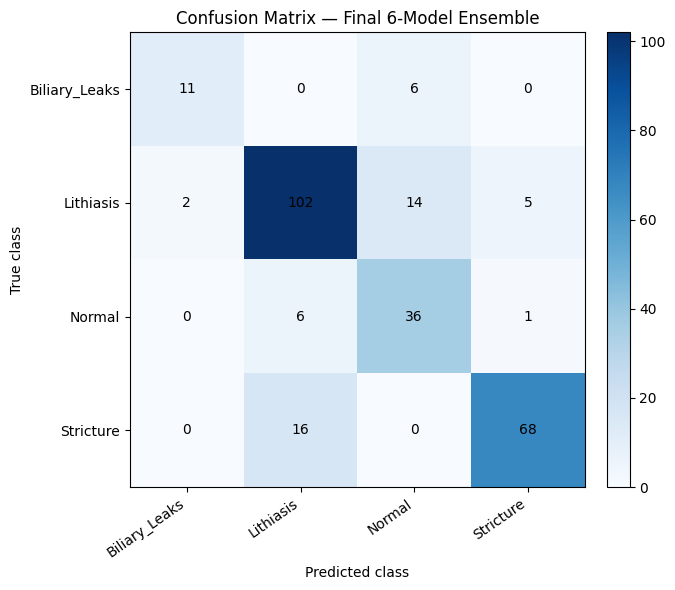

Saved: /kaggle/working/final_6_model_outputs/final_6_model_confusion_matrix.png


In [31]:
FINAL_OUTPUT_DIR = Path("/kaggle/working/final_6_model_outputs")
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_report_dict = classification_report(
    y_test_multiclass,
    final_selected_test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)

final_report_df = pd.DataFrame(final_report_dict).transpose()
display(final_report_df.round(4))

final_cm = confusion_matrix(
    y_test_multiclass,
    final_selected_test_preds,
    labels=list(range(NUM_CLASSES)),
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(final_cm, cmap="Blues")
ax.set_title("Confusion Matrix — Final 6-Model Ensemble")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax.set_yticklabels(CLASS_NAMES)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(final_cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = FINAL_OUTPUT_DIR / "final_6_model_confusion_matrix.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

## 18. Macro AUC-ROC

AUC-ROC is computed one-vs-rest. For the hybrid system, the `Biliary_Leaks` score is replaced by the specialist probability and the remaining class scores come from the final blended multiclass probabilities.

In [32]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


def build_hybrid_scores(multiclass_scores, biliary_probs, class_names):
    hybrid_scores = multiclass_scores.copy()
    biliary_idx = class_names.index("Biliary_Leaks")
    hybrid_scores[:, biliary_idx] = biliary_probs
    return hybrid_scores


def compute_ovr_auc(y_true, class_scores, class_names, split_name, model_name):
    labels = list(range(len(class_names)))
    y_true_bin = label_binarize(y_true, classes=labels)

    rows = []
    for class_idx, class_name in enumerate(class_names):
        auc_value = roc_auc_score(y_true_bin[:, class_idx], class_scores[:, class_idx])
        rows.append({
            "Model": model_name,
            "Split": split_name,
            "Class": class_name,
            "AUC-ROC": auc_value,
        })

    macro_auc = np.mean([row["AUC-ROC"] for row in rows])
    rows.append({
        "Model": model_name,
        "Split": split_name,
        "Class": "macro_avg",
        "AUC-ROC": macro_auc,
    })

    return pd.DataFrame(rows)


final_selected_test_scores = build_hybrid_scores(
    final_selected_test_probs,
    binary_test_probs,
    CLASS_NAMES,
)

final_auc_df = compute_ovr_auc(
    y_true=y_test_multiclass,
    class_scores=final_selected_test_scores,
    class_names=CLASS_NAMES,
    split_name="test",
    model_name=FINAL_MODEL_NAME,
)

display(final_auc_df.round(4))
print("Final Test Macro AUC-ROC:", final_auc_df.loc[final_auc_df["Class"] == "macro_avg", "AUC-ROC"].iloc[0])

,Model,Split,Class,AUC-ROC
0,Final blend + EfficientNet-B0 + Biliary Specia...,test,Biliary_Leaks,0.9289
1,Final blend + EfficientNet-B0 + Biliary Specia...,test,Lithiasis,0.8882
2,Final blend + EfficientNet-B0 + Biliary Specia...,test,Normal,0.9489
3,Final blend + EfficientNet-B0 + Biliary Specia...,test,Stricture,0.9532
4,Final blend + EfficientNet-B0 + Biliary Specia...,test,macro_avg,0.9298


Final Test Macro AUC-ROC: 0.9297944894932682


## 19. TP / FP / FN / TN counts

In [33]:
def compute_multiclass_one_vs_rest_counts(y_true, y_pred, class_names):
    rows = []
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for class_idx, class_name in enumerate(class_names):
        true_positive = int(np.sum((y_true == class_idx) & (y_pred == class_idx)))
        false_positive = int(np.sum((y_true != class_idx) & (y_pred == class_idx)))
        false_negative = int(np.sum((y_true == class_idx) & (y_pred != class_idx)))
        true_negative = int(np.sum((y_true != class_idx) & (y_pred != class_idx)))

        rows.append({
            "Class": class_name,
            "TP": true_positive,
            "FP": false_positive,
            "FN": false_negative,
            "TN": true_negative,
            "Support": int(np.sum(y_true == class_idx)),
        })

    return pd.DataFrame(rows)


final_counts_df = compute_multiclass_one_vs_rest_counts(
    y_test_multiclass,
    final_selected_test_preds,
    CLASS_NAMES,
)

display(final_counts_df)

,Class,TP,FP,FN,TN,Support
0,Biliary_Leaks,11,2,6,248,17
1,Lithiasis,102,22,21,122,123
2,Normal,36,20,7,204,43
3,Stricture,68,6,16,177,84


## 20. Save final metrics and predictions

In [34]:
import json

final_metrics = {
    "model_name": FINAL_MODEL_NAME,
    "b0_alpha": float(FINAL_ALPHA_B0),
    "biliary_threshold": float(FINAL_BILIARY_THRESHOLD),
    "val_accuracy": float(final_selected_val_eval["accuracy"]),
    "val_macro_f1": float(final_selected_val_eval["macro_f1"]),
    "test_accuracy": float(final_selected_test_eval["accuracy"]),
    "test_macro_f1": float(final_selected_test_eval["macro_f1"]),
    "test_macro_auc_roc": float(final_auc_df.loc[final_auc_df["Class"] == "macro_avg", "AUC-ROC"].iloc[0]),
}

with open(FINAL_OUTPUT_DIR / "final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

final_comparison_table.to_csv(FINAL_OUTPUT_DIR / "final_comparison_table.csv", index=False)
final_report_df.to_csv(FINAL_OUTPUT_DIR / "final_classification_report.csv")
final_auc_df.to_csv(FINAL_OUTPUT_DIR / "final_auc_roc.csv", index=False)
final_counts_df.to_csv(FINAL_OUTPUT_DIR / "final_tp_fp_fn_tn_counts.csv", index=False)

np.save(FINAL_OUTPUT_DIR / "final_test_probs.npy", final_selected_test_probs)
np.save(FINAL_OUTPUT_DIR / "final_test_preds.npy", final_selected_test_preds)
np.save(FINAL_OUTPUT_DIR / "final_test_labels.npy", y_test_multiclass)

print(json.dumps(final_metrics, indent=2))
print("Saved final outputs to:", FINAL_OUTPUT_DIR)

{
  "model_name": "Final blend + EfficientNet-B0 + Biliary Specialist",
  "b0_alpha": 0.08,
  "biliary_threshold": 0.86,
  "val_accuracy": 0.7307692307692307,
  "val_macro_f1": 0.6941544957117636,
  "test_accuracy": 0.8127340823970037,
  "test_macro_f1": 0.7868191213627589,
  "test_macro_auc_roc": 0.9297944894932682
}
Saved final outputs to: /kaggle/working/final_6_model_outputs


## 21. Occlusion sensitivity

Occlusion sensitivity is used as an additional interpretability method. Cases involving `Biliary_Leaks` are explained with the binary specialist, while the remaining examples are explained with ConvNeXt-Tiny.

In [35]:
# Occlusion sensitivity analysis

from PIL import Image

OCCLUSION_OUTPUT_DIR = Path("/kaggle/working/occlusion_analysis_final_6_model")
OCCLUSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def build_case_table(image_files, y_true, y_pred, blended_probs, biliary_probs, threshold, split_name):
    rows = []
    base_pred = np.argmax(blended_probs, axis=1)
    biliary_override = biliary_probs >= threshold

    for idx, path in enumerate(image_files):
        true_idx = int(y_true[idx])
        pred_idx = int(y_pred[idx])
        base_pred_idx = int(base_pred[idx])

        rows.append({
            "split": split_name,
            "idx": idx,
            "path": str(path),
            "filename": Path(path).name,
            "true_idx": true_idx,
            "pred_idx": pred_idx,
            "base_pred_idx": base_pred_idx,
            "true_class": CLASS_NAMES[true_idx],
            "pred_class": CLASS_NAMES[pred_idx],
            "base_pred_class": CLASS_NAMES[base_pred_idx],
            "correct": true_idx == pred_idx,
            "predicted_probability": float(blended_probs[idx, pred_idx]),
            "true_class_probability": float(blended_probs[idx, true_idx]),
            "max_blended_probability": float(np.max(blended_probs[idx])),
            "biliary_specialist_probability": float(biliary_probs[idx]),
            "biliary_override": bool(biliary_override[idx]),
        })

    return pd.DataFrame(rows)


test_case_table = build_case_table(
    image_files=binary_test_files,
    y_true=y_test_multiclass,
    y_pred=final_selected_test_preds,
    blended_probs=final_selected_test_probs,
    biliary_probs=binary_test_probs,
    threshold=FINAL_BILIARY_THRESHOLD,
    split_name="test",
)

BILIARY_CLASS = "Biliary_Leaks"
STRICTURE_CLASS = "Stricture"
BILIARY_IDX = CLASS_NAMES.index(BILIARY_CLASS)
STRICTURE_IDX = CLASS_NAMES.index(STRICTURE_CLASS)


biliary_tp_cases = test_case_table[
    (test_case_table["true_class"] == BILIARY_CLASS) &
    (test_case_table["pred_class"] == BILIARY_CLASS)
].sort_values(by="biliary_specialist_probability", ascending=False).head(1)

lithiasis_tp_cases = test_case_table[
    (test_case_table["true_class"] == "Lithiasis") &
    (test_case_table["pred_class"] == "Lithiasis")
].sort_values(by="predicted_probability", ascending=False).head(1)

normal_tp_cases = test_case_table[
    (test_case_table["true_class"] == "Normal") &
    (test_case_table["pred_class"] == "Normal")
].sort_values(by="predicted_probability", ascending=False).head(1)

stricture_tp_cases = test_case_table[
    (test_case_table["true_class"] == STRICTURE_CLASS) &
    (test_case_table["pred_class"] == STRICTURE_CLASS)
].sort_values(by="predicted_probability", ascending=False).head(1)

error_cases = test_case_table[
    test_case_table["true_class"] != test_case_table["pred_class"]
].sort_values(by="predicted_probability", ascending=False).head(1)

selected_interpretability_cases = pd.concat([
    biliary_tp_cases.assign(analysis_group="Biliary_Leaks correct prediction"),
    lithiasis_tp_cases.assign(analysis_group="Lithiasis correct prediction"),
    normal_tp_cases.assign(analysis_group="Normal correct prediction"),
    stricture_tp_cases.assign(analysis_group="Stricture correct prediction"),
    error_cases.assign(analysis_group="Incorrect prediction example"),
], ignore_index=True)

selected_interpretability_cases.to_csv(
    OCCLUSION_OUTPUT_DIR / "selected_interpretability_cases.csv",
    index=False
)

display(selected_interpretability_cases[[
    "analysis_group", "idx", "filename", "true_class", "pred_class",
    "predicted_probability", "true_class_probability",
    "biliary_specialist_probability", "biliary_override"
]])

,analysis_group,idx,filename,true_class,pred_class,predicted_probability,true_class_probability,biliary_specialist_probability,biliary_override
0,Biliary_Leaks correct prediction,8,1391_1391_image17609.png,Biliary_Leaks,Biliary_Leaks,0.739157,0.739157,0.960886,True
1,Lithiasis correct prediction,99,682_682_image7908.png,Lithiasis,Lithiasis,0.980912,0.980912,0.006029,False
2,Normal correct prediction,154,1550_1550_image18921_section_2.png,Normal,Normal,0.813726,0.813726,0.014312,False
3,Stricture correct prediction,249,742_742_image8728.png,Stricture,Stricture,0.904502,0.904502,0.521023,False
4,Incorrect prediction example,113,714_714_image8333.png,Lithiasis,Normal,0.928459,0.039261,0.003447,False


In [36]:
# Occlusion utility functions


def load_tensor_from_path(path):
    x = eval_transforms(str(path))
    if x.ndim == 3:
        x = x.unsqueeze(0)
    return x.to(device)


def load_image_for_display(path, size=(512, 512)):
    img = Image.open(path).convert("L")
    img = img.resize(size)
    arr = np.asarray(img).astype(np.float32)
    arr = arr - arr.min()
    arr = arr / (arr.max() + 1e-8)
    return arr


@torch.no_grad()
def get_model_score(model, input_batch, target_class, mode):
    model.eval()
    logits = model(input_batch)

    if mode == "binary_biliary":
        probs = torch.sigmoid(logits.reshape(-1))
        return probs

    if mode == "multiclass":
        probs = torch.softmax(logits, dim=1)
        return probs[:, target_class]

    raise ValueError("mode must be 'binary_biliary' or 'multiclass'.")


@torch.no_grad()
def occlusion_sensitivity_map(model, input_tensor, target_class, mode,
                              patch_size=32, stride=16, fill_value=0.0, batch_size=16):
    model.eval()

    baseline_score = get_model_score(
        model=model,
        input_batch=input_tensor,
        target_class=target_class,
        mode=mode,
    )[0].item()

    _, _, H, W = input_tensor.shape
    heatmap = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.float32)

    occluded_tensors = []
    coordinates = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = input_tensor.clone()
            occluded[:, :, y:y + patch_size, x:x + patch_size] = fill_value
            occluded_tensors.append(occluded)
            coordinates.append((y, x))

            if len(occluded_tensors) == batch_size:
                batch = torch.cat(occluded_tensors, dim=0)
                scores = get_model_score(model, batch, target_class, mode)
                drops = baseline_score - scores.detach().cpu().numpy()

                for drop, (yy, xx) in zip(drops, coordinates):
                    heatmap[yy:yy + patch_size, xx:xx + patch_size] += drop
                    counts[yy:yy + patch_size, xx:xx + patch_size] += 1

                occluded_tensors = []
                coordinates = []

    if len(occluded_tensors) > 0:
        batch = torch.cat(occluded_tensors, dim=0)
        scores = get_model_score(model, batch, target_class, mode)
        drops = baseline_score - scores.detach().cpu().numpy()

        for drop, (yy, xx) in zip(drops, coordinates):
            heatmap[yy:yy + patch_size, xx:xx + patch_size] += drop
            counts[yy:yy + patch_size, xx:xx + patch_size] += 1

    heatmap = heatmap / np.maximum(counts, 1)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)

    return heatmap, baseline_score


def show_and_save_occlusion(case_row, model, target_class, mode, model_name, analysis_group,
                            patch_size=32, stride=16):
    path = Path(case_row["path"])
    input_tensor = load_tensor_from_path(path)
    raw_img = load_image_for_display(path)

    occ_map, baseline_score = occlusion_sensitivity_map(
        model=model,
        input_tensor=input_tensor,
        target_class=target_class,
        mode=mode,
        patch_size=patch_size,
        stride=stride,
        fill_value=0.0,
        batch_size=16,
    )

    target_class_name = CLASS_NAMES[target_class]
    safe_group = analysis_group.lower().replace(" ", "_")
    safe_target = target_class_name.lower().replace(" ", "_")

    out_path = OCCLUSION_OUTPUT_DIR / (
        f"occlusion_{safe_group}_idx_{int(case_row['idx'])}_{model_name}_target_{safe_target}.png"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(raw_img, cmap="gray")
    axes[0].axis("off")
    axes[0].set_title("Original image")

    axes[1].imshow(occ_map, cmap="jet", interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(f"Occlusion map\nTarget: {target_class_name}")

    axes[2].imshow(raw_img, cmap="gray")
    axes[2].imshow(occ_map, cmap="jet", alpha=0.35, interpolation="bilinear")
    axes[2].axis("off")
    axes[2].set_title("Overlay")

    plt.suptitle(
        f"{analysis_group}\n"
        f"Test idx={int(case_row['idx'])} | True: {case_row['true_class']} | "
        f"Final prediction: {case_row['pred_class']} | Explained model: {model_name}\n"
        f"Target: {target_class_name} | Baseline score: {baseline_score:.3f} | "
        f"Biliary specialist prob: {case_row['biliary_specialist_probability']:.3f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

    return {
        "analysis_group": analysis_group,
        "idx": int(case_row["idx"]),
        "filename": case_row["filename"],
        "true_class": case_row["true_class"],
        "pred_class": case_row["pred_class"],
        "explained_model": model_name,
        "target_class": target_class_name,
        "baseline_score": baseline_score,
        "output_path": str(out_path),
    }

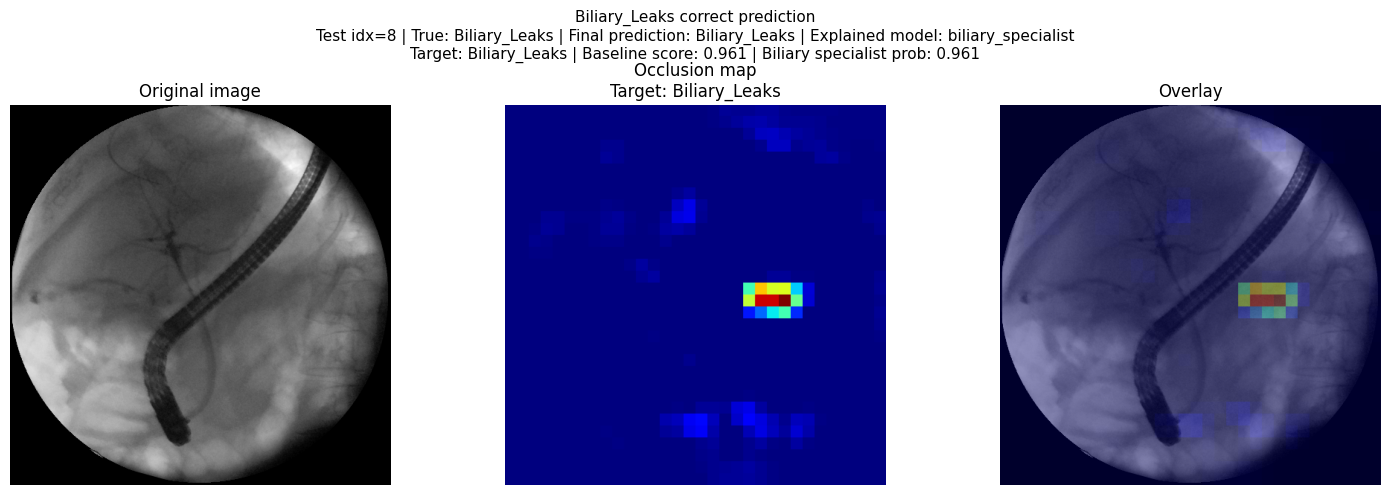

Saved: /kaggle/working/occlusion_analysis_final_6_model/occlusion_biliary_leaks_correct_prediction_idx_8_biliary_specialist_target_biliary_leaks.png


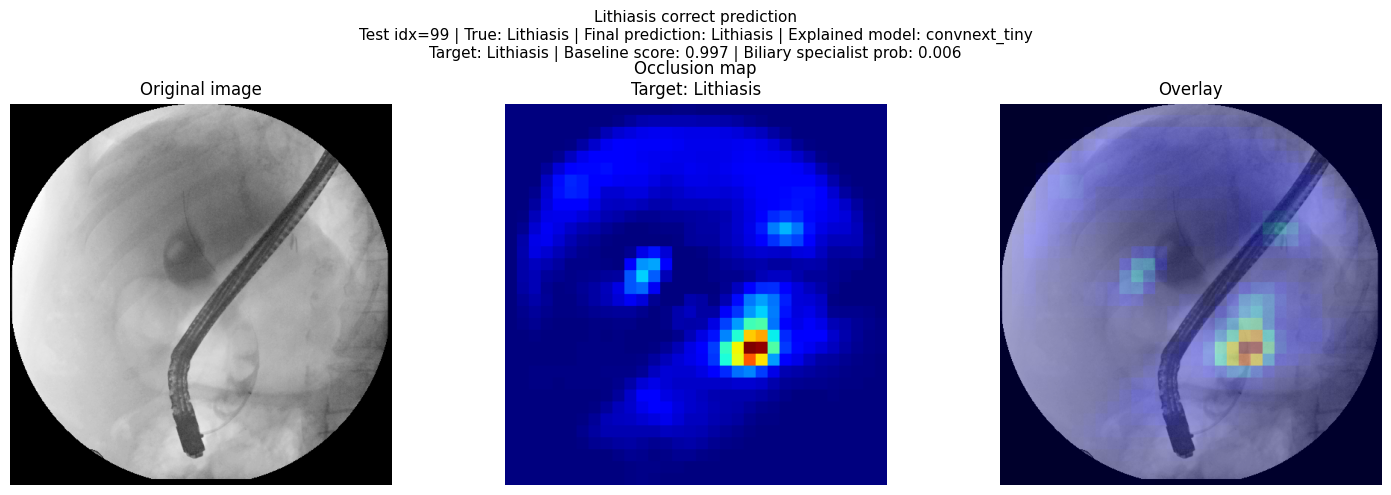

Saved: /kaggle/working/occlusion_analysis_final_6_model/occlusion_lithiasis_correct_prediction_idx_99_convnext_tiny_target_lithiasis.png


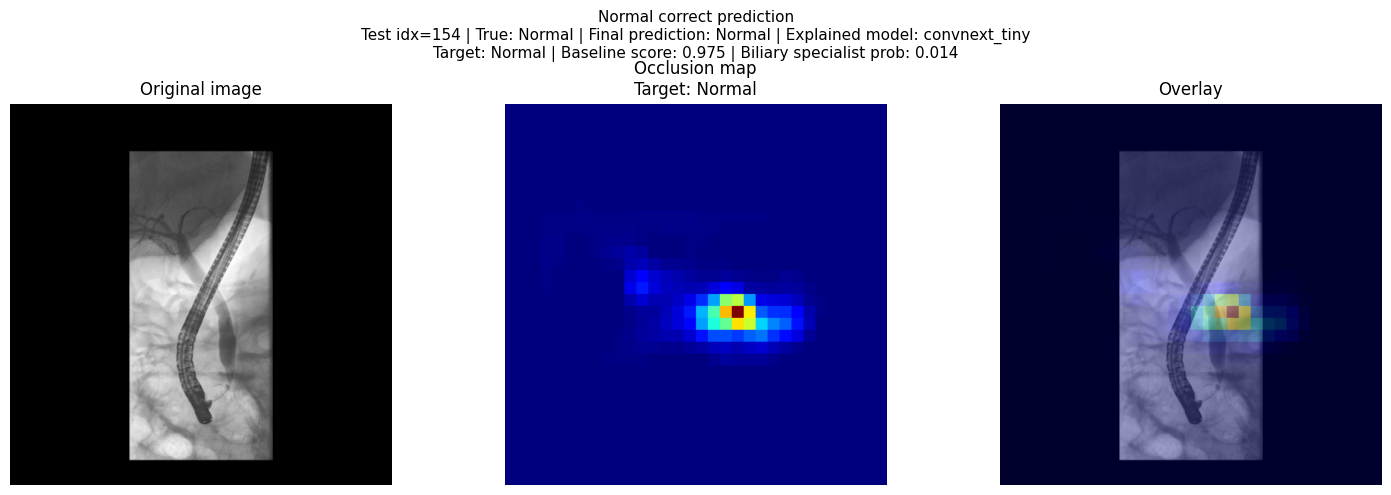

Saved: /kaggle/working/occlusion_analysis_final_6_model/occlusion_normal_correct_prediction_idx_154_convnext_tiny_target_normal.png


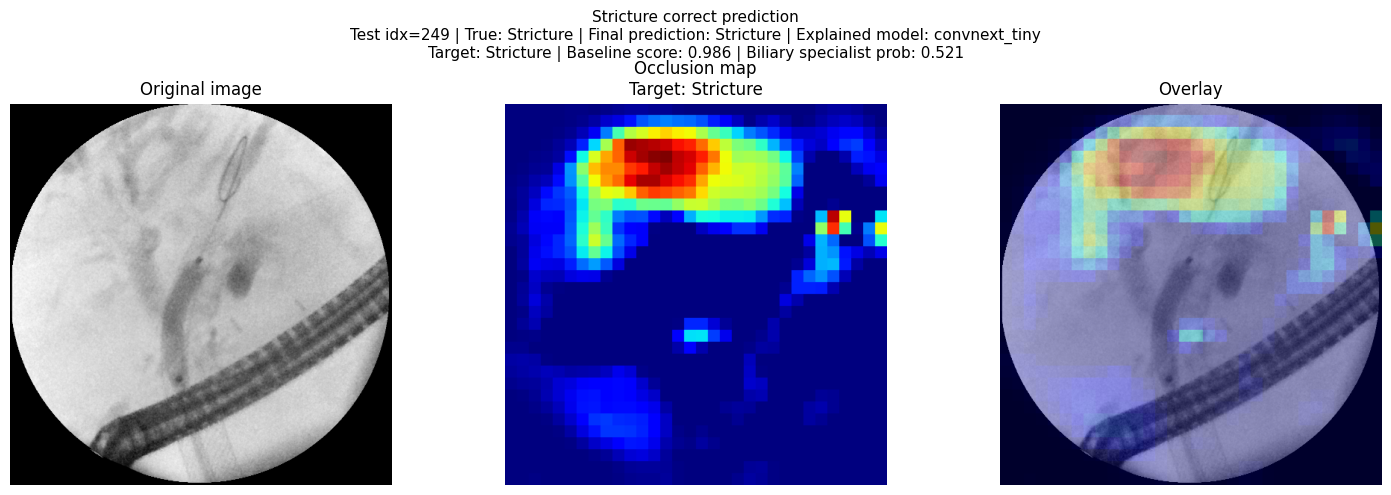

Saved: /kaggle/working/occlusion_analysis_final_6_model/occlusion_stricture_correct_prediction_idx_249_convnext_tiny_target_stricture.png


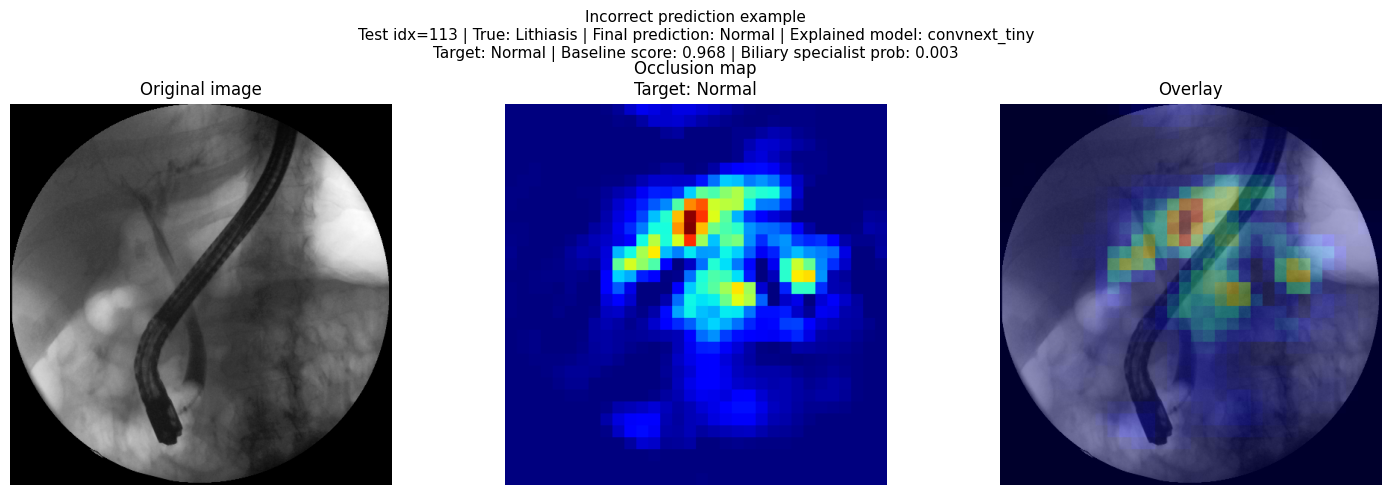

Saved: /kaggle/working/occlusion_analysis_final_6_model/occlusion_incorrect_prediction_example_idx_113_convnext_tiny_target_normal.png


,analysis_group,idx,filename,true_class,pred_class,explained_model,target_class,baseline_score,output_path
0,Biliary_Leaks correct prediction,8,1391_1391_image17609.png,Biliary_Leaks,Biliary_Leaks,biliary_specialist,Biliary_Leaks,0.960885,/kaggle/working/occlusion_analysis_final_6_mod...
1,Lithiasis correct prediction,99,682_682_image7908.png,Lithiasis,Lithiasis,convnext_tiny,Lithiasis,0.997392,/kaggle/working/occlusion_analysis_final_6_mod...
2,Normal correct prediction,154,1550_1550_image18921_section_2.png,Normal,Normal,convnext_tiny,Normal,0.975294,/kaggle/working/occlusion_analysis_final_6_mod...
3,Stricture correct prediction,249,742_742_image8728.png,Stricture,Stricture,convnext_tiny,Stricture,0.985546,/kaggle/working/occlusion_analysis_final_6_mod...
4,Incorrect prediction example,113,714_714_image8333.png,Lithiasis,Normal,convnext_tiny,Normal,0.968242,/kaggle/working/occlusion_analysis_final_6_mod...


/kaggle/working/occlusion_analysis_final_6_model.zip

In [37]:
# Generate occlusion figures

binary_occlusion_model = binary_model.to(device)
binary_occlusion_model.eval()

convnext_occlusion_model = convnext_model.to(device)
convnext_occlusion_model.eval()

occlusion_summary_rows = []

for _, row in selected_interpretability_cases.iterrows():

    if row["true_class"] == "Biliary_Leaks" or row["pred_class"] == "Biliary_Leaks":
        # Explain the specialist whenever Biliary_Leaks is involved.
        occlusion_summary_rows.append(show_and_save_occlusion(
            case_row=row,
            model=binary_occlusion_model,
            target_class=BILIARY_IDX,
            mode="binary_biliary",
            model_name="biliary_specialist",
            analysis_group=row["analysis_group"],
            patch_size=32,
            stride=16,
        ))

    else:
        # For multiclass examples, explain the class predicted by the model.
        occlusion_summary_rows.append(show_and_save_occlusion(
            case_row=row,
            model=convnext_occlusion_model,
            target_class=int(row["pred_idx"]),
            mode="multiclass",
            model_name="convnext_tiny",
            analysis_group=row["analysis_group"],
            patch_size=32,
            stride=16,
        ))

occlusion_summary_df = pd.DataFrame(occlusion_summary_rows)
occlusion_summary_df.to_csv(OCCLUSION_OUTPUT_DIR / "occlusion_summary.csv", index=False)
display(occlusion_summary_df)

occlusion_zip_path = "/kaggle/working/occlusion_analysis_final_6_model.zip"
if Path(occlusion_zip_path).exists():
    Path(occlusion_zip_path).unlink()

shutil.make_archive(
    base_name=occlusion_zip_path.replace(".zip", ""),
    format="zip",
    root_dir="/kaggle/working",
    base_dir="occlusion_analysis_final_6_model",
)


import os
from IPython.display import FileLink, display
os.chdir("/kaggle/working")
display(FileLink("occlusion_analysis_final_6_model.zip"))

## 22. Grad-CAM

Grad-CAM is the main interpretability method required for the report. The same selected cases used for occlusion are reused here.

In [38]:
# Grad-CAM utility functions

GRADCAM_OUTPUT_DIR = Path("/kaggle/working/gradcam_analysis_final_6_model")
GRADCAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from scipy.ndimage import gaussian_filter


def clear_all_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()
        module._backward_pre_hooks.clear()


def to_plain_tensor(x):
    if hasattr(x, "as_tensor"):
        x = x.as_tensor()
    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x)
    return x.clone().detach().float()


def load_tensor_for_gradcam(path):
    x = eval_transforms(str(path))
    x = to_plain_tensor(x)
    if x.ndim == 3:
        x = x.unsqueeze(0)
    return x.to(device)


def find_used_last_conv_layer(model, sample_tensor, model_name="model"):
    model.eval()
    conv_outputs = []
    hooks = []

    def make_hook(name, module):
        def hook(module, inputs, output):
            if isinstance(output, torch.Tensor) and output.ndim == 4:
                _, _, h, w = output.shape
                if h > 1 and w > 1:
                    conv_outputs.append({
                        "name": name,
                        "module": module,
                        "shape": tuple(output.shape),
                    })
        return hook

    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            hooks.append(module.register_forward_hook(make_hook(name, module)))

    with torch.no_grad():
        _ = model(sample_tensor)

    for hook in hooks:
        hook.remove()

    if len(conv_outputs) == 0:
        raise RuntimeError(f"No usable Conv2d layer was activated for {model_name}.")

    selected = conv_outputs[-1]
    print(f"[{model_name}] Selected Grad-CAM layer:")
    print("Layer:", selected["name"])
    print("Output shape:", selected["shape"])

    return selected["module"], selected["name"]


class StableGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.forward_handle = self.target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output

    def remove_hooks(self):
        self.forward_handle.remove()

    def __call__(self, input_tensor, target_class=None, mode="multiclass"):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        self.activations = None

        input_tensor = input_tensor.clone().detach().to(device).float()
        input_tensor.requires_grad_(True)

        with torch.enable_grad():
            logits = self.model(input_tensor)

            if self.activations is None:
                raise RuntimeError("Forward hook did not capture activations.")

            if mode == "binary_biliary":
                logit = logits.reshape(-1)[0]
                score = logit
                model_score = torch.sigmoid(logit).item()

            elif mode == "multiclass":
                if logits.ndim == 1:
                    logits = logits.unsqueeze(0)
                if target_class is None:
                    target_class = int(torch.argmax(logits, dim=1).item())
                score = logits[0, target_class]
                model_score = torch.softmax(logits, dim=1)[0, target_class].item()

            else:
                raise ValueError("mode must be 'binary_biliary' or 'multiclass'.")

            grads = torch.autograd.grad(
                outputs=score,
                inputs=self.activations,
                retain_graph=False,
                create_graph=False,
                allow_unused=False,
            )[0]

        activations = self.activations.detach()
        grads = grads.detach()

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        # Smooth only for clearer visualization.
        cam = gaussian_filter(cam, sigma=1.2)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, model_score

In [39]:
# Load models and create Grad-CAM objects

clear_all_hooks(binary_model)
clear_all_hooks(convnext_model)

binary_gradcam_model = binary_model.to(device)
binary_gradcam_model.eval()

convnext_gradcam_model = convnext_model.to(device)
convnext_gradcam_model.eval()

sample_biliary_path = selected_interpretability_cases[
    (selected_interpretability_cases["true_class"] == "Biliary_Leaks") |
    (selected_interpretability_cases["pred_class"] == "Biliary_Leaks")
].iloc[0]["path"]

sample_biliary_tensor = load_tensor_for_gradcam(sample_biliary_path)

sample_convnext_path = selected_interpretability_cases[
    ~(
        (selected_interpretability_cases["true_class"] == "Biliary_Leaks") |
        (selected_interpretability_cases["pred_class"] == "Biliary_Leaks")
    )
].iloc[0]["path"]

sample_convnext_tensor = load_tensor_for_gradcam(sample_convnext_path)

binary_target_layer, binary_target_layer_name = find_used_last_conv_layer(
    binary_gradcam_model,
    sample_biliary_tensor,
    model_name="biliary_specialist",
)

convnext_target_layer, convnext_target_layer_name = find_used_last_conv_layer(
    convnext_gradcam_model,
    sample_convnext_tensor,
    model_name="convnext_tiny",
)

binary_gradcam = StableGradCAM(binary_gradcam_model, binary_target_layer)
convnext_gradcam = StableGradCAM(convnext_gradcam_model, convnext_target_layer)

print("Grad-CAM models ready.")
print("Biliary specialist layer:", binary_target_layer_name)
print("ConvNeXt layer:", convnext_target_layer_name)

[biliary_specialist] Selected Grad-CAM layer:
Layer: features.8.0
Output shape: (1, 2560, 16, 16)
[convnext_tiny] Selected Grad-CAM layer:
Layer: features.7.2.block.0
Output shape: (1, 768, 16, 16)
Grad-CAM models ready.
Biliary specialist layer: features.8.0
ConvNeXt layer: features.7.2.block.0


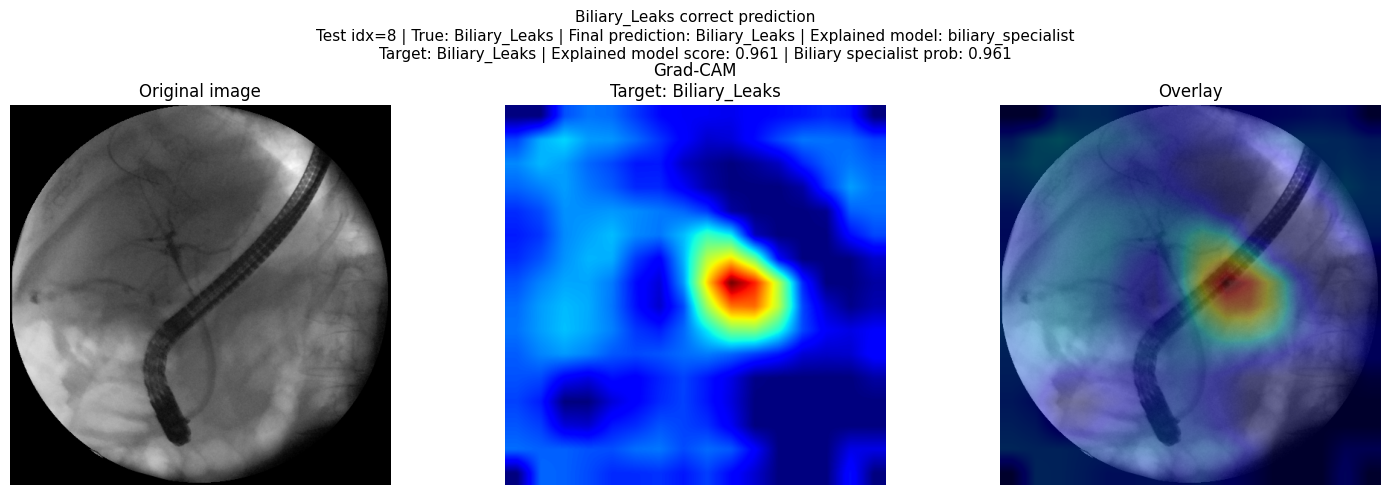

Saved: /kaggle/working/gradcam_analysis_final_6_model/gradcam_biliary_leaks_correct_prediction_idx_8_biliary_specialist_target_biliary_leaks.png


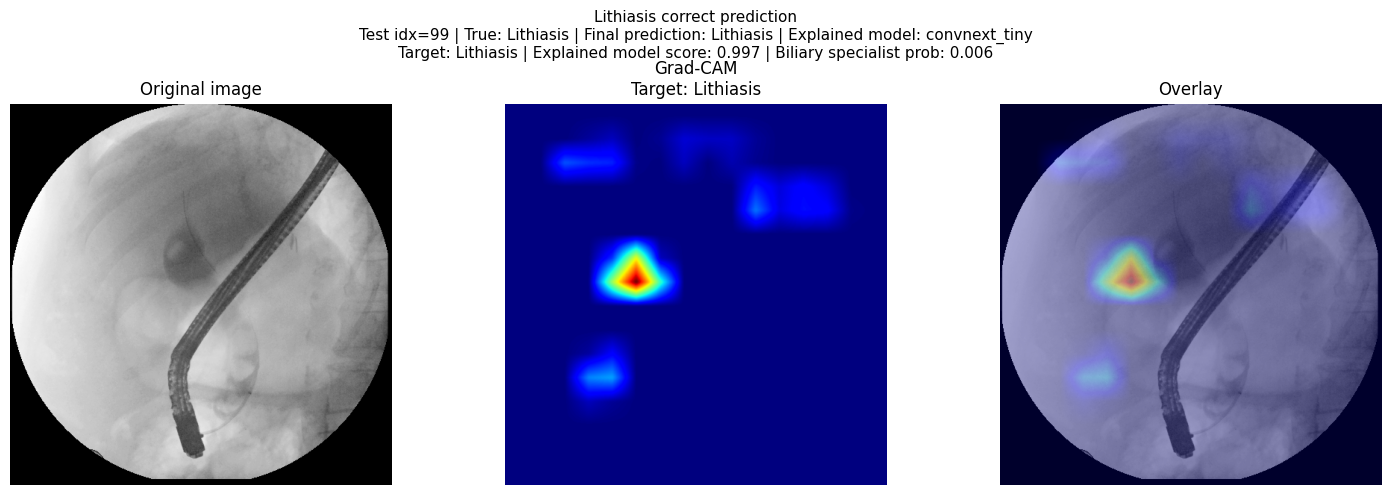

Saved: /kaggle/working/gradcam_analysis_final_6_model/gradcam_lithiasis_correct_prediction_idx_99_convnext_tiny_target_lithiasis.png


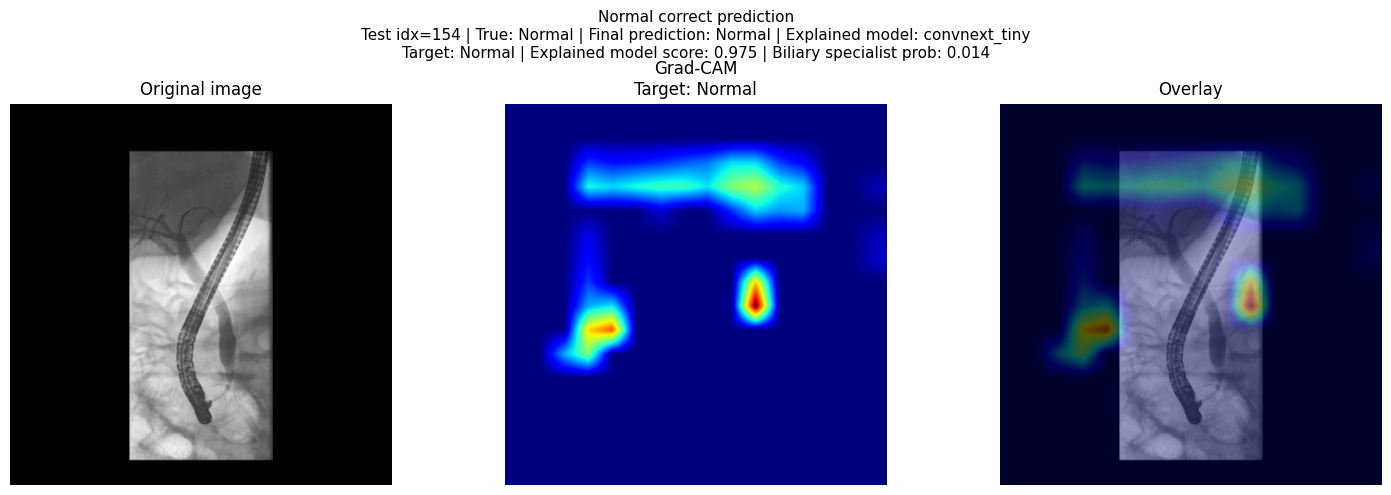

Saved: /kaggle/working/gradcam_analysis_final_6_model/gradcam_normal_correct_prediction_idx_154_convnext_tiny_target_normal.png


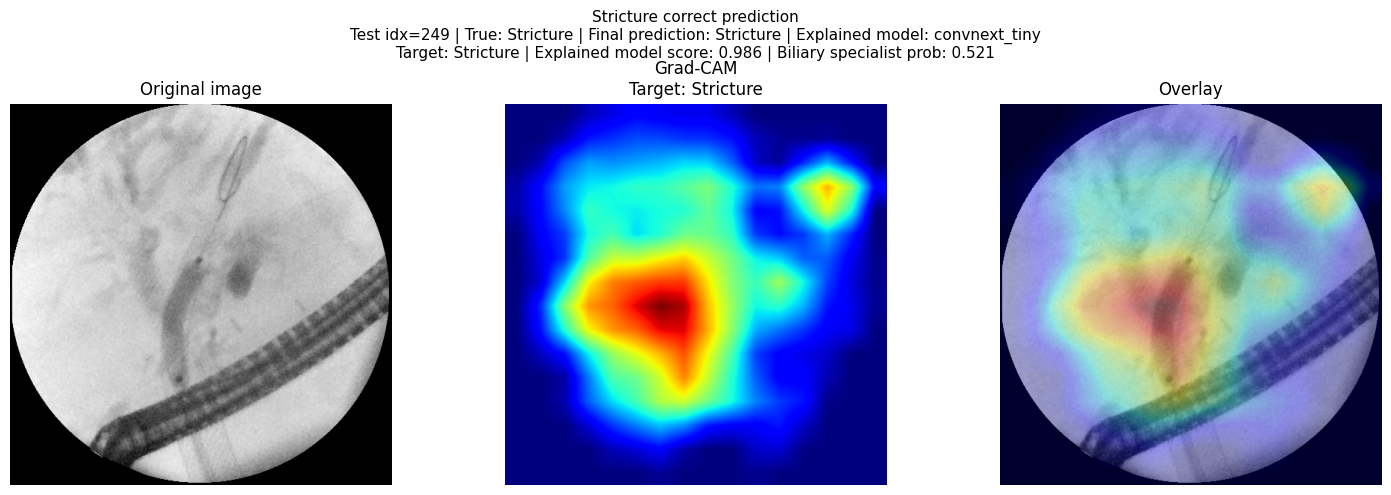

Saved: /kaggle/working/gradcam_analysis_final_6_model/gradcam_stricture_correct_prediction_idx_249_convnext_tiny_target_stricture.png


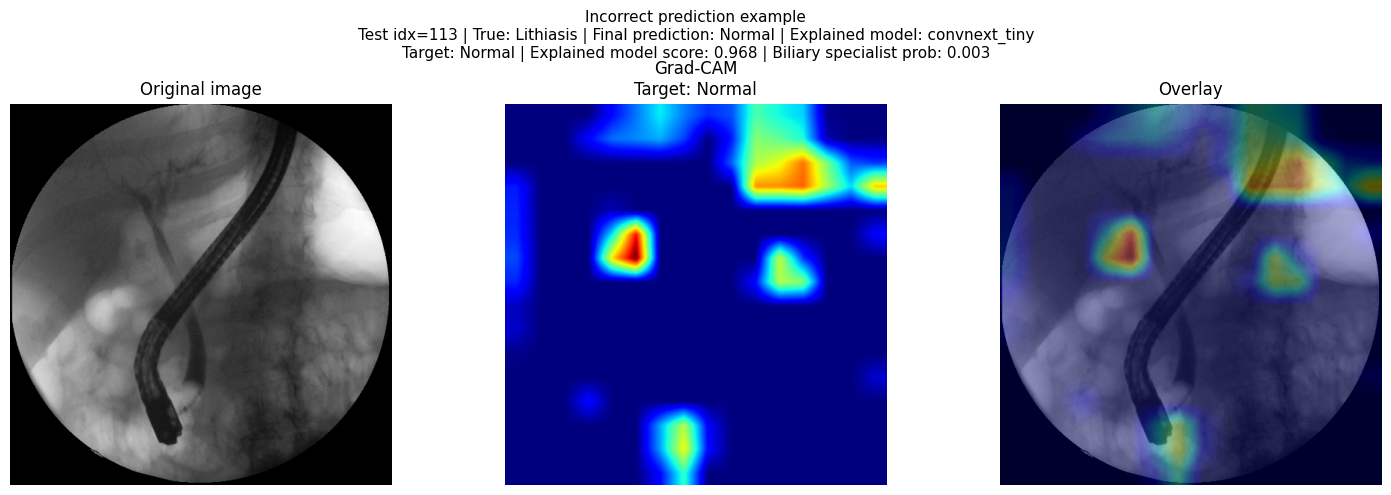

Saved: /kaggle/working/gradcam_analysis_final_6_model/gradcam_incorrect_prediction_example_idx_113_convnext_tiny_target_normal.png


,analysis_group,idx,filename,true_class,pred_class,explained_model,target_class,model_score,output_path
0,Biliary_Leaks correct prediction,8,1391_1391_image17609.png,Biliary_Leaks,Biliary_Leaks,biliary_specialist,Biliary_Leaks,0.960885,/kaggle/working/gradcam_analysis_final_6_model...
1,Lithiasis correct prediction,99,682_682_image7908.png,Lithiasis,Lithiasis,convnext_tiny,Lithiasis,0.997392,/kaggle/working/gradcam_analysis_final_6_model...
2,Normal correct prediction,154,1550_1550_image18921_section_2.png,Normal,Normal,convnext_tiny,Normal,0.975294,/kaggle/working/gradcam_analysis_final_6_model...
3,Stricture correct prediction,249,742_742_image8728.png,Stricture,Stricture,convnext_tiny,Stricture,0.985546,/kaggle/working/gradcam_analysis_final_6_model...
4,Incorrect prediction example,113,714_714_image8333.png,Lithiasis,Normal,convnext_tiny,Normal,0.968242,/kaggle/working/gradcam_analysis_final_6_model...


Grad-CAM analysis saved to:
/kaggle/working/gradcam_analysis_final_6_model


/kaggle/working/gradcam_analysis_final_6_model.zip

In [40]:
# Generate Grad-CAM figures


def show_and_save_gradcam(case_row, gradcam_object, model_name, target_class, mode, analysis_group):
    path = Path(case_row["path"])
    input_tensor = load_tensor_for_gradcam(path)
    raw_img = load_image_for_display(path)

    cam, model_score = gradcam_object(
        input_tensor=input_tensor,
        target_class=target_class,
        mode=mode,
    )

    target_class_name = CLASS_NAMES[target_class]
    safe_group = analysis_group.lower().replace(" ", "_")
    safe_target = target_class_name.lower().replace(" ", "_")

    out_path = GRADCAM_OUTPUT_DIR / (
        f"gradcam_{safe_group}_idx_{int(case_row['idx'])}_{model_name}_target_{safe_target}.png"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(raw_img, cmap="gray")
    axes[0].axis("off")
    axes[0].set_title("Original image")

    axes[1].imshow(cam, cmap="jet", interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(f"Grad-CAM\nTarget: {target_class_name}")

    axes[2].imshow(raw_img, cmap="gray")
    axes[2].imshow(cam, cmap="jet", alpha=0.35, interpolation="bilinear")
    axes[2].axis("off")
    axes[2].set_title("Overlay")

    plt.suptitle(
        f"{analysis_group}\n"
        f"Test idx={int(case_row['idx'])} | True: {case_row['true_class']} | "
        f"Final prediction: {case_row['pred_class']} | Explained model: {model_name}\n"
        f"Target: {target_class_name} | Explained model score: {model_score:.3f} | "
        f"Biliary specialist prob: {case_row['biliary_specialist_probability']:.3f}",
        fontsize=11,
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

    return {
        "analysis_group": analysis_group,
        "idx": int(case_row["idx"]),
        "filename": case_row["filename"],
        "true_class": case_row["true_class"],
        "pred_class": case_row["pred_class"],
        "explained_model": model_name,
        "target_class": target_class_name,
        "model_score": float(model_score),
        "output_path": str(out_path),
    }


gradcam_summary_rows = []

for _, row in selected_interpretability_cases.iterrows():

    if row["true_class"] == "Biliary_Leaks" or row["pred_class"] == "Biliary_Leaks":
        # Explain the Biliary specialist whenever the case involves Biliary_Leaks.
        gradcam_summary_rows.append(show_and_save_gradcam(
            case_row=row,
            gradcam_object=binary_gradcam,
            model_name="biliary_specialist",
            target_class=BILIARY_IDX,
            mode="binary_biliary",
            analysis_group=row["analysis_group"],
        ))

    else:
        # For multiclass cases, explain the class predicted by the model.
        gradcam_summary_rows.append(show_and_save_gradcam(
            case_row=row,
            gradcam_object=convnext_gradcam,
            model_name="convnext_tiny",
            target_class=int(row["pred_idx"]),
            mode="multiclass",
            analysis_group=row["analysis_group"],
        ))

gradcam_summary_df = pd.DataFrame(gradcam_summary_rows)
gradcam_summary_df.to_csv(GRADCAM_OUTPUT_DIR / "gradcam_summary.csv", index=False)
display(gradcam_summary_df)

print("Grad-CAM analysis saved to:")
print(GRADCAM_OUTPUT_DIR)

gradcam_zip_path = "/kaggle/working/gradcam_analysis_final_6_model.zip"
if Path(gradcam_zip_path).exists():
    Path(gradcam_zip_path).unlink()

shutil.make_archive(
    base_name=gradcam_zip_path.replace(".zip", ""),
    format="zip",
    root_dir="/kaggle/working",
    base_dir="gradcam_analysis_final_6_model",
)



import os
from IPython.display import FileLink, display
os.chdir("/kaggle/working")
display(FileLink("gradcam_analysis_final_6_model.zip"))

## 23. Package all final outputs

In [41]:
# Zip final output folders for download

import os
import shutil
from IPython.display import FileLink, display

WORKING_DIR = Path("/kaggle/working")
FINAL_ZIP_BASE = "/tmp/final_6_model_outputs_package"
FINAL_ZIP_PATH = WORKING_DIR / "final_6_model_outputs_package.zip"

if Path(FINAL_ZIP_BASE + ".zip").exists():
    Path(FINAL_ZIP_BASE + ".zip").unlink()

if FINAL_ZIP_PATH.exists():
    FINAL_ZIP_PATH.unlink()

# Collect the most important output folders/files under /kaggle/working.
shutil.make_archive(
    base_name=FINAL_ZIP_BASE,
    format="zip",
    root_dir=str(WORKING_DIR),
    base_dir=".",
)

shutil.copy2(FINAL_ZIP_BASE + ".zip", FINAL_ZIP_PATH)

os.chdir("/kaggle/working")
print("Final package:", FINAL_ZIP_PATH)
print("Size MB:", FINAL_ZIP_PATH.stat().st_size / (1024 ** 2))
display(FileLink(FINAL_ZIP_PATH.name))

Final package: /kaggle/working/final_6_model_outputs_package.zip
Size MB: 243.46416187286377


/kaggle/working/final_6_model_outputs_package.zip